## 1. Importing the libraries

In [147]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc, roc_curve

## 2. Configuration to use in the file

In [112]:
# Dataset Configuration
DATASET_PATH = "./heart_disease.csv"
TARGET_COLUMN = "target"

# Train test split configuration
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Preprocessing
SCALER = StandardScaler()

# Model configuration
KERNEL = "rbf"
SVC_PARAMS = {
    "kernel": KERNEL,
    "random_state": RANDOM_STATE,
    "probability": True
}


# Visualization configuration
FIGURE_SIZE = (14, 14)
ALPHA = 0.6

## 3. Helper Functions

In [142]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print("Accuracy score: ", accuracy_score(y_test, y_pred))

    print("\nROC AUC score: ", roc_auc_score(y_test, y_pred_proba))

    cm = confusion_matrix(y_test, y_pred)
    print("\n Confusion matrix: \n", cm)

    print("\n Classification report: \n", classification_report(y_test, y_pred))

In [114]:
def display_prediction_example(model, prediction_example):
    for example_name, example_data in prediction_example.items():
        prediction = model.predict(example_data)[0]

        print(f"\nScenario : {example_name}")
        print("-" * 20)
        print(example_data)

        print(f"\nPrediction Breaking distance: {prediction:.2f}")

In [153]:
def plot_feature_importance(model, X_train, y_train, feature_names):
    result = permutation_importance(
        model,
        X_train,
        y_train,
        n_repeats=10,
        random_state=42,
        scoring="accuracy",
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": result.importances_mean
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=FIGURE_SIZE)
    sns.barplot(
        data=importance_df, 
        x="Importance", 
        y="Feature", 
        palette="magma",
        hue="Feature",
        legend=False
    )
    
    plt.title("Permutation Feature Importance for Employee Attrition", fontsize=14, pad=15)
    plt.xlabel("Mean Decrease in Accuracy", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=ALPHA)

    plt.tight_layout()
    plt.show()

In [115]:
def plot_roc_curve(model, X_test, y_test):
    y_scores = model.decision_function(X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=FIGURE_SIZE)

    plt.plot(fpr, tpr, label='SVM ROC Curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0,1], [0,1], linestyle='--')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('SVM ROC Curve')
    plt.legend()
    plt.show()

In [116]:
def plot_correlation_heatmap(df, numeric_col):
    corr = df[numeric_col].corr()

    plt.figure(figsize=FIGURE_SIZE)

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Heatmap for correlation analysis")
    plt.show()

## 4. Loading the dataset

In [117]:
df = pd.read_csv(DATASET_PATH)

## 5. Understanding the dataset / Dataset overview

In [118]:
df.shape

(303, 14)

In [119]:
df.columns

Index(['age', 'gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [120]:
df.head()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [121]:
df.isnull().sum()

age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [122]:
df.duplicated().sum()

np.int64(1)

#### Dropping the duplicates

In [123]:
df.drop_duplicates(inplace=True)

In [124]:
df.shape

(302, 14)

#### Continuing the analysis

In [125]:
df.info()

<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   gender    302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [126]:
df.describe()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [127]:
df["chol"].quantile(0.99)

np.float64(406.8700000000001)

In [128]:
df["trestbps"].quantile(0.99)

np.float64(180.0)

In [129]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

The target data of the dataset is pretty balanced but the values in the columns *chol* and *trestbps* have a high variance which can indicate potential outliers

## 6. Defining feature list

In [130]:
NUMERICAL_COLUMNS = df.select_dtypes(include='number').columns.to_list()

## 7. Outlier analysis

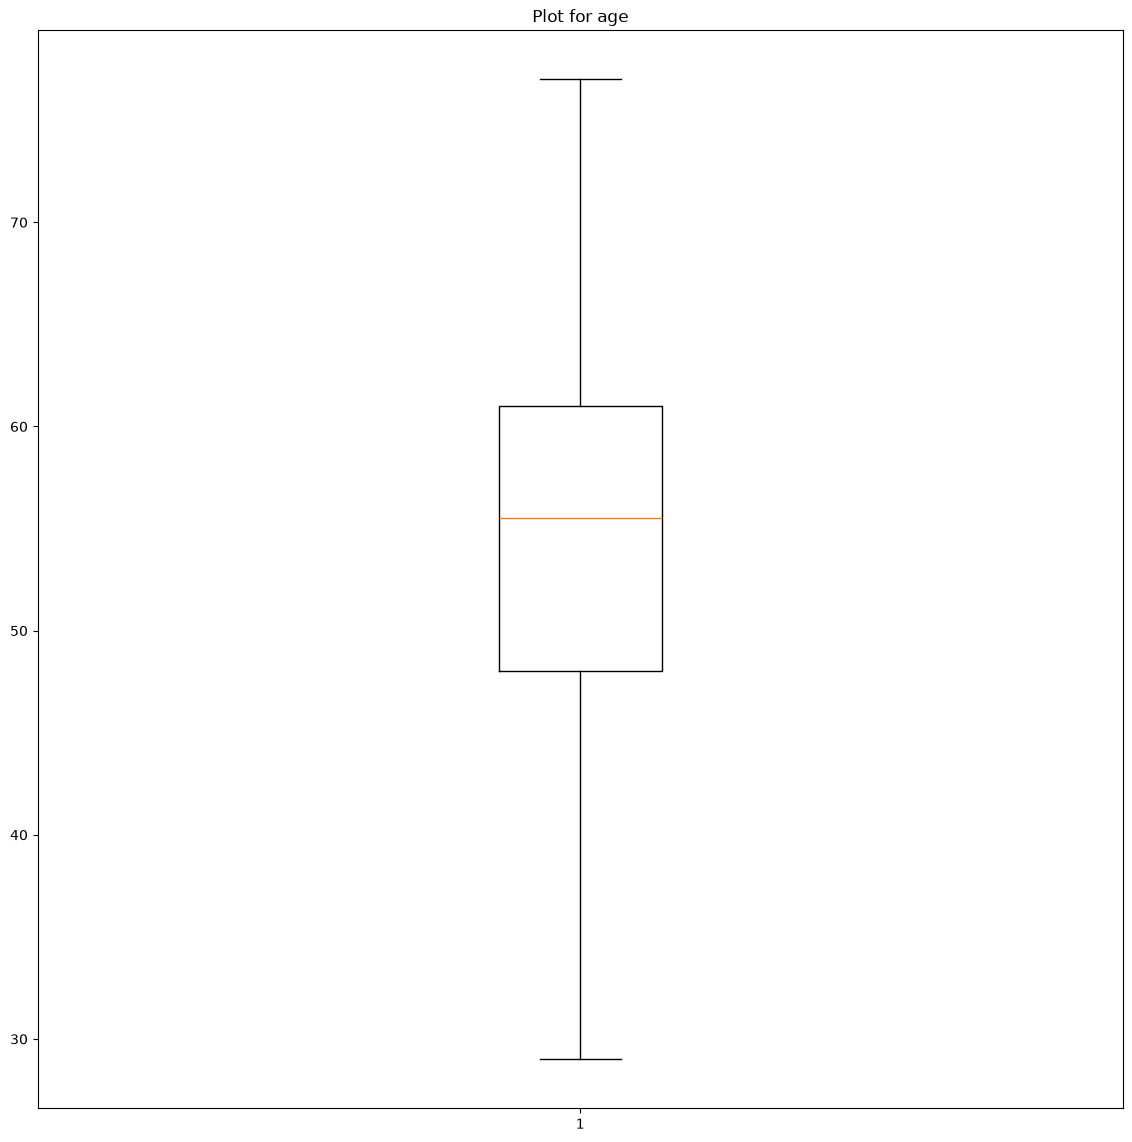

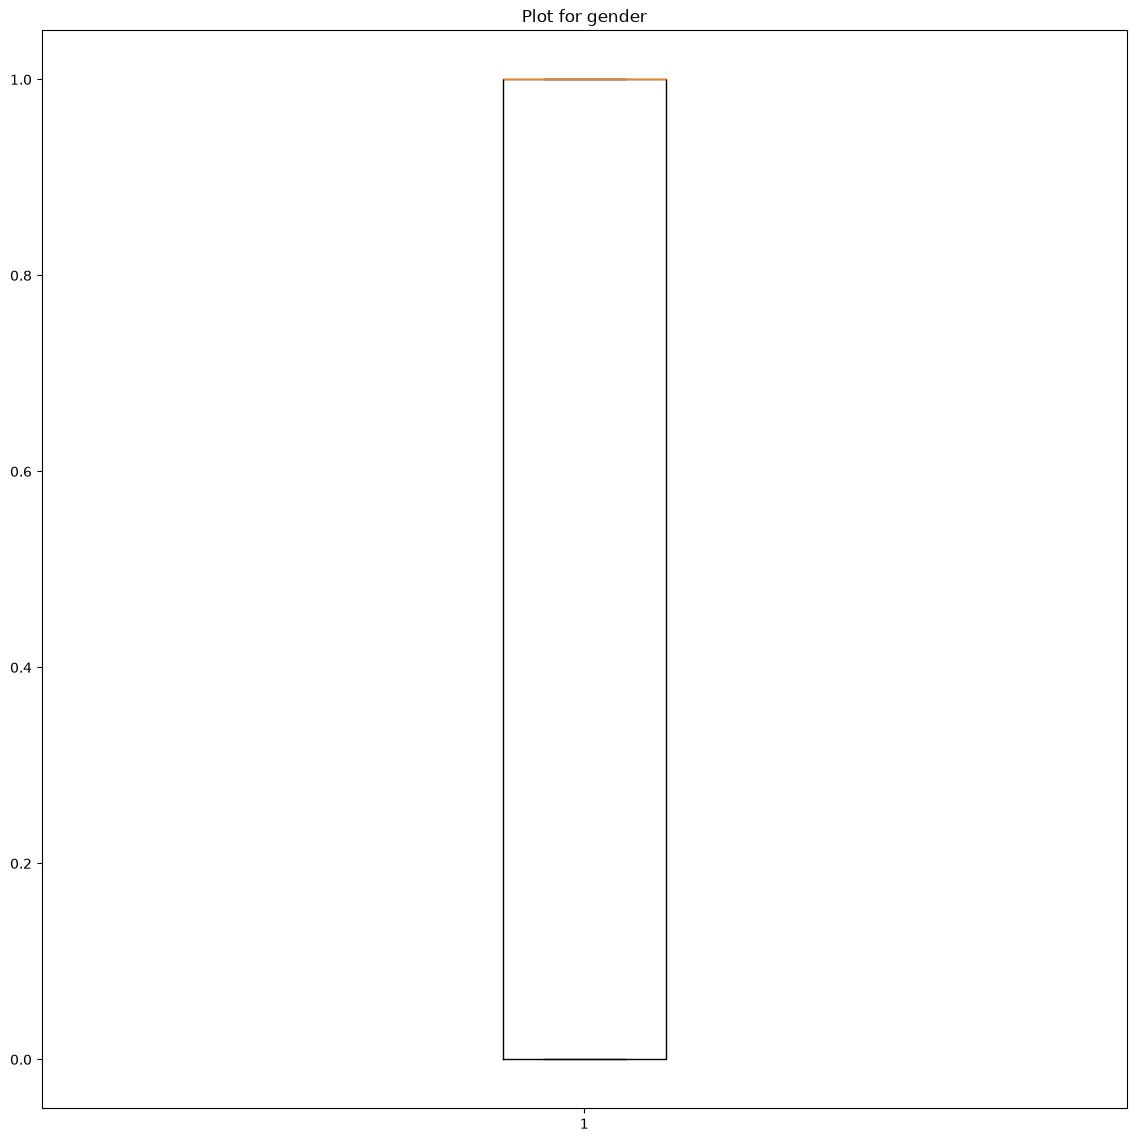

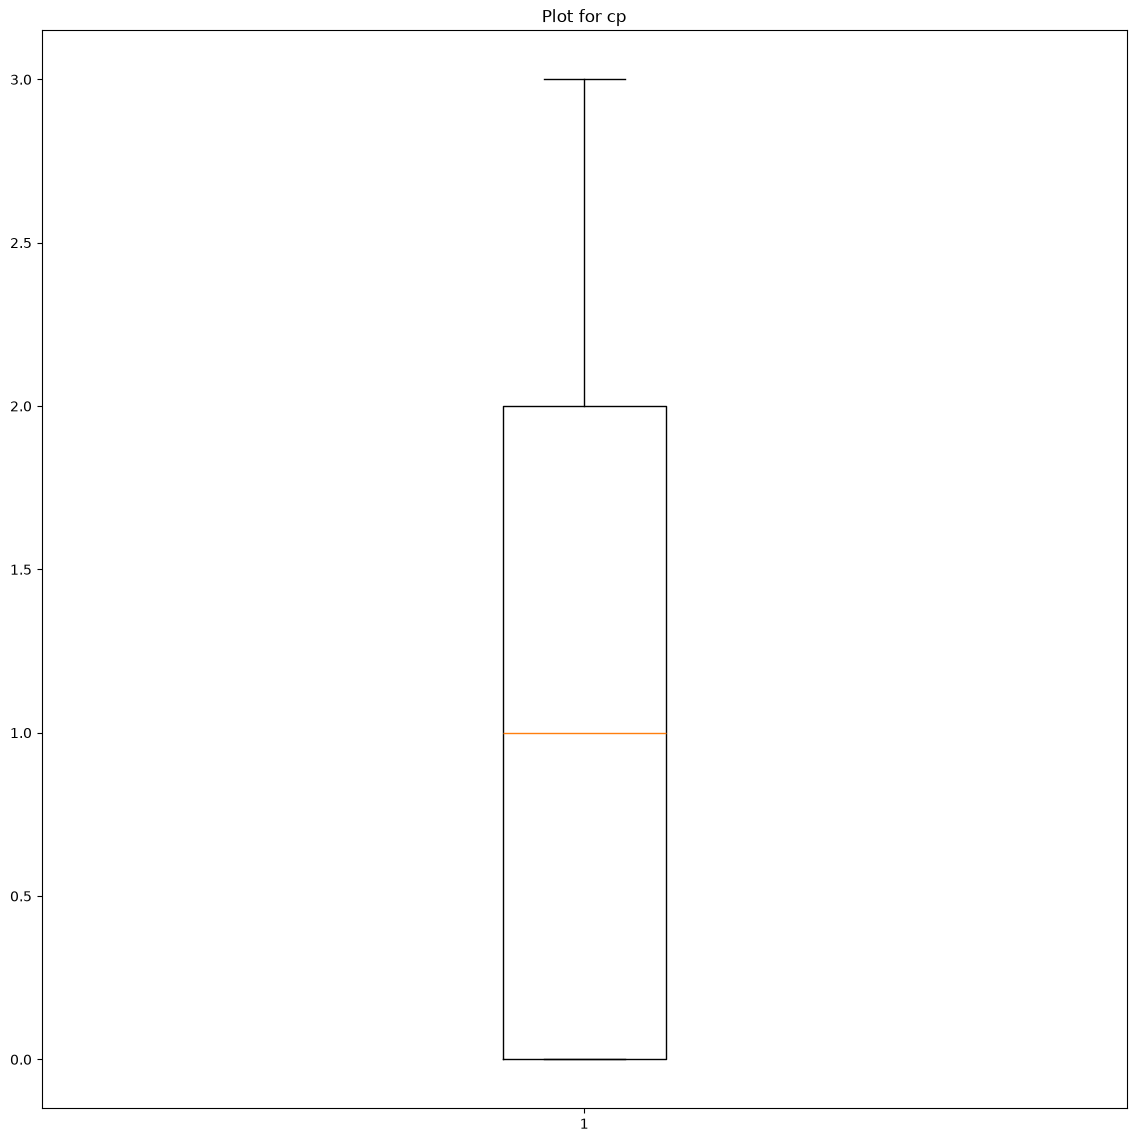

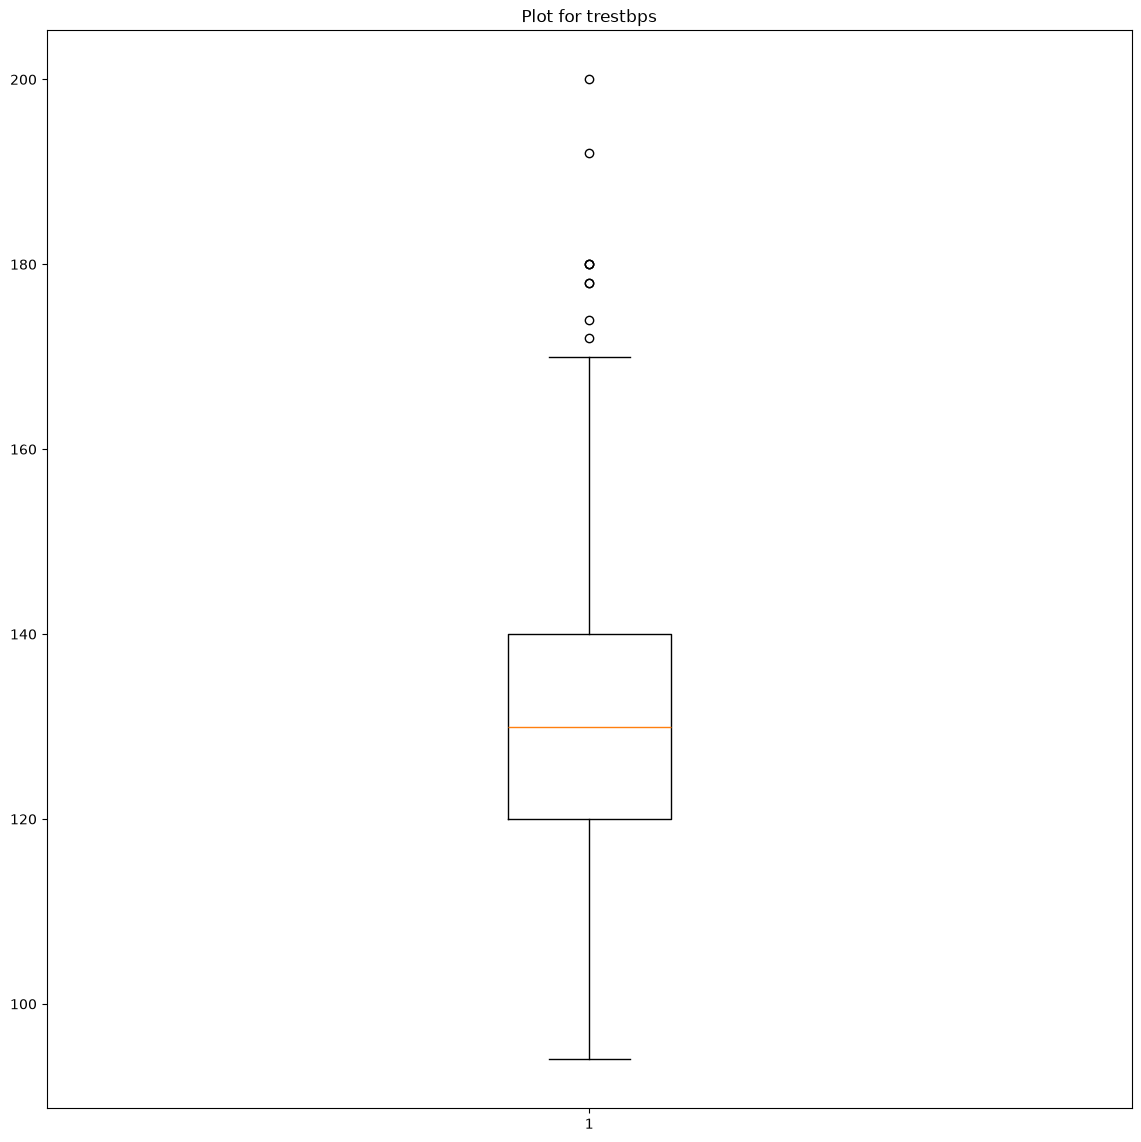

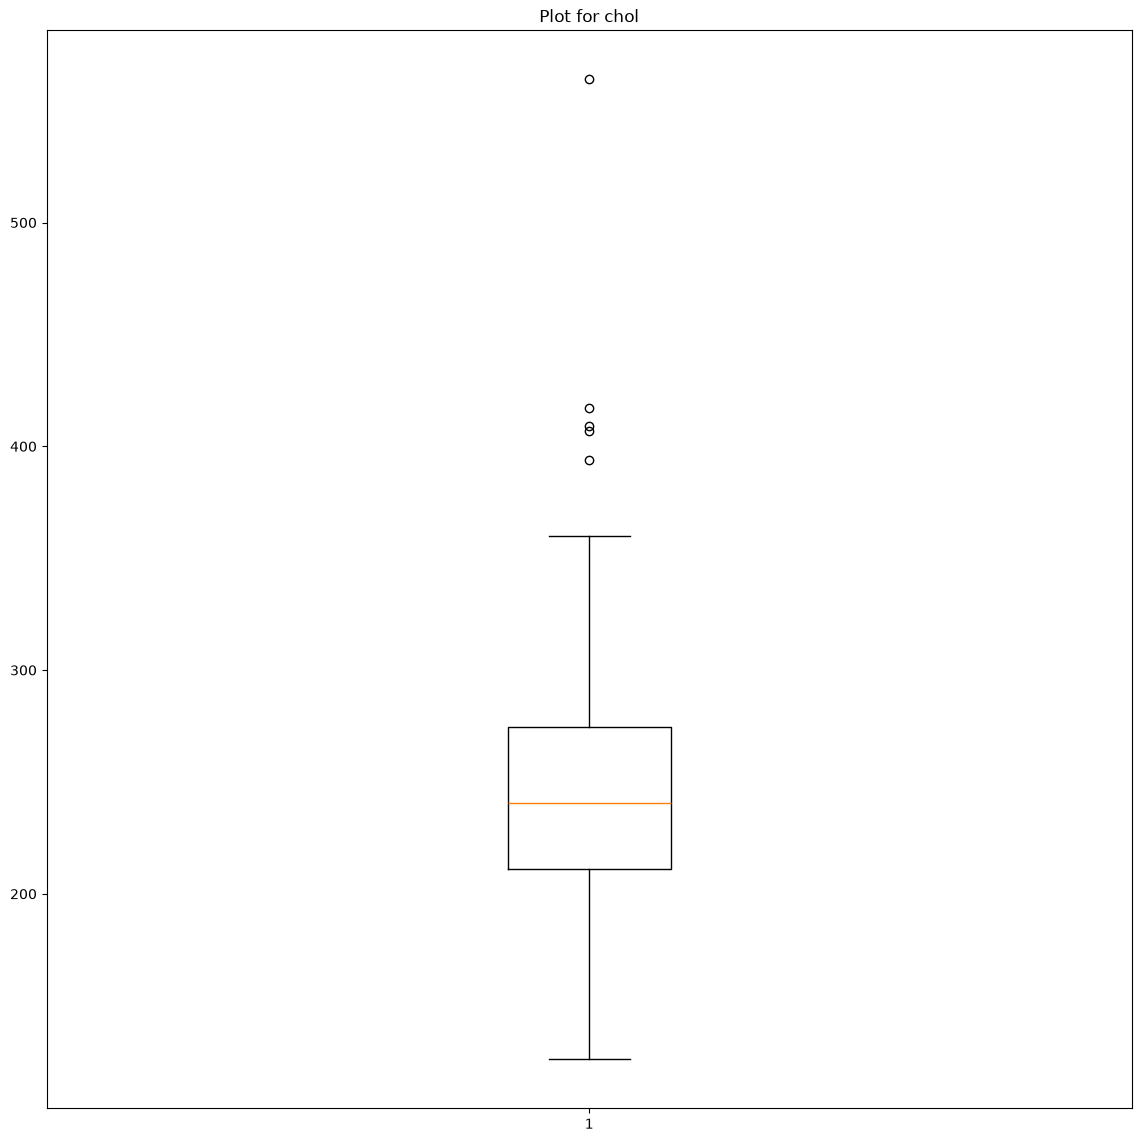

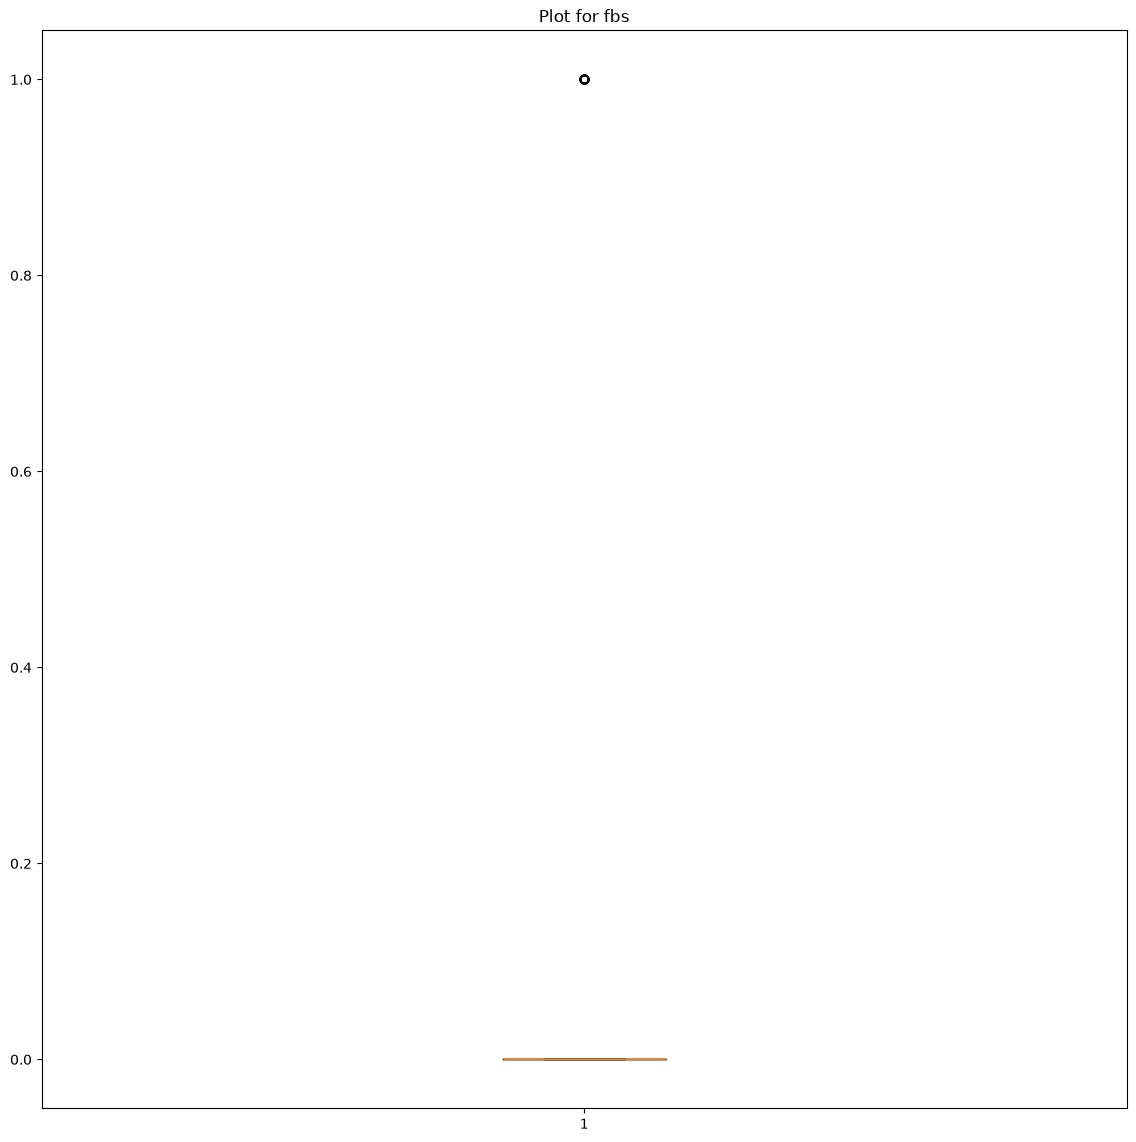

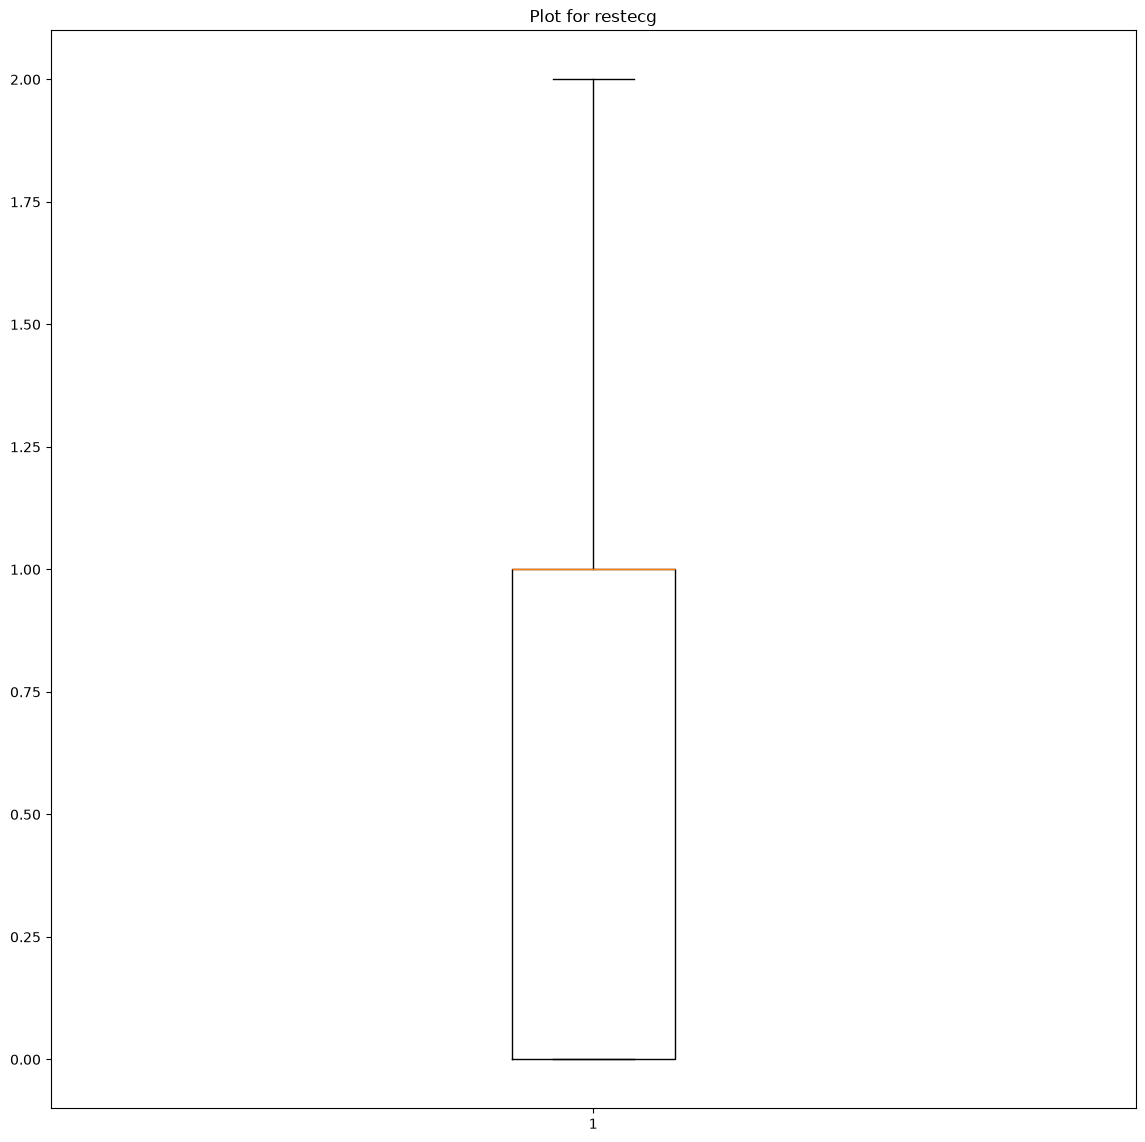

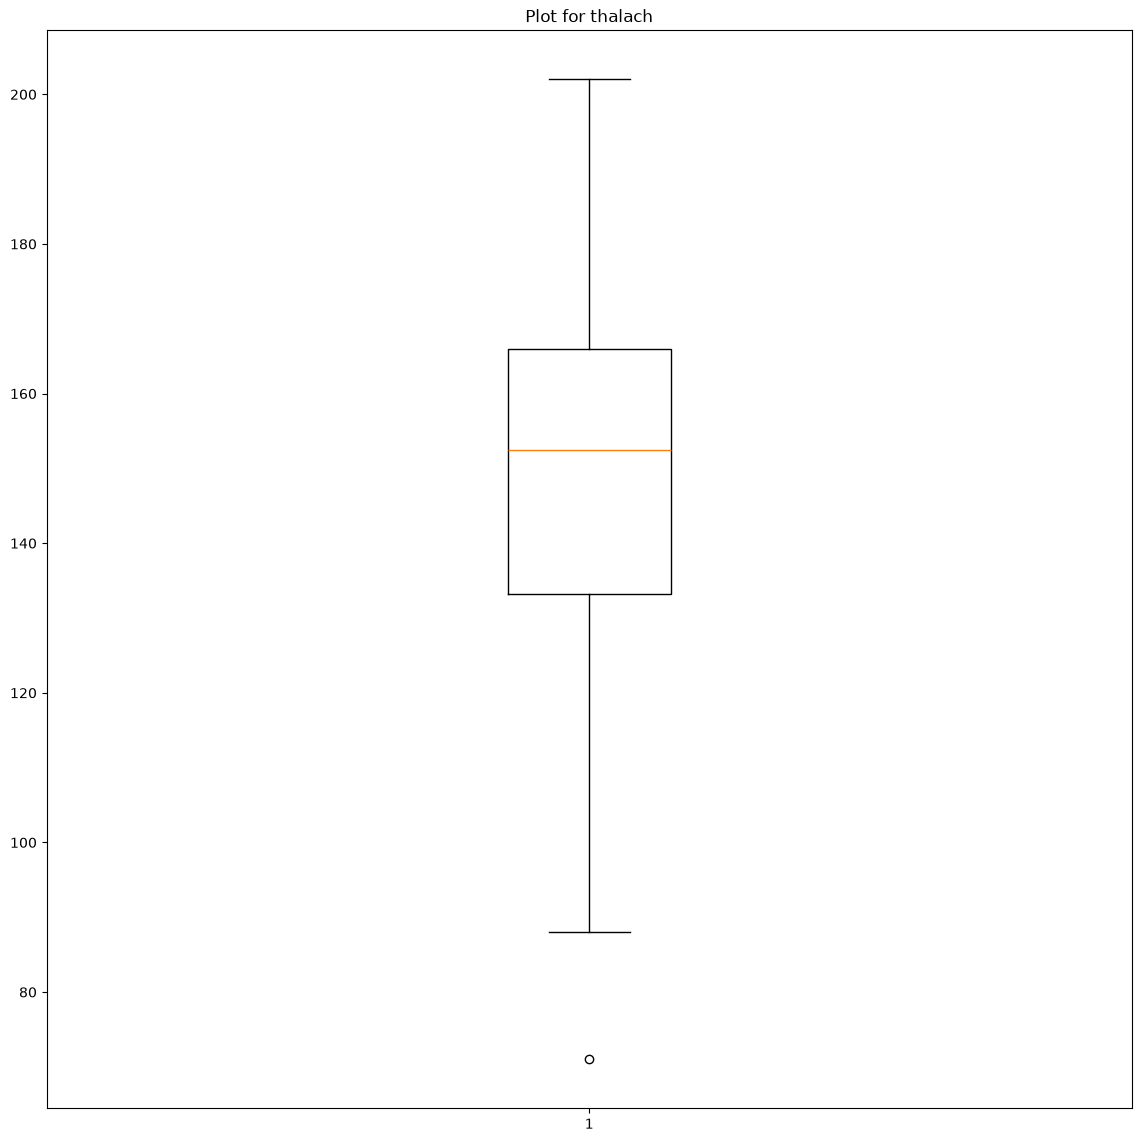

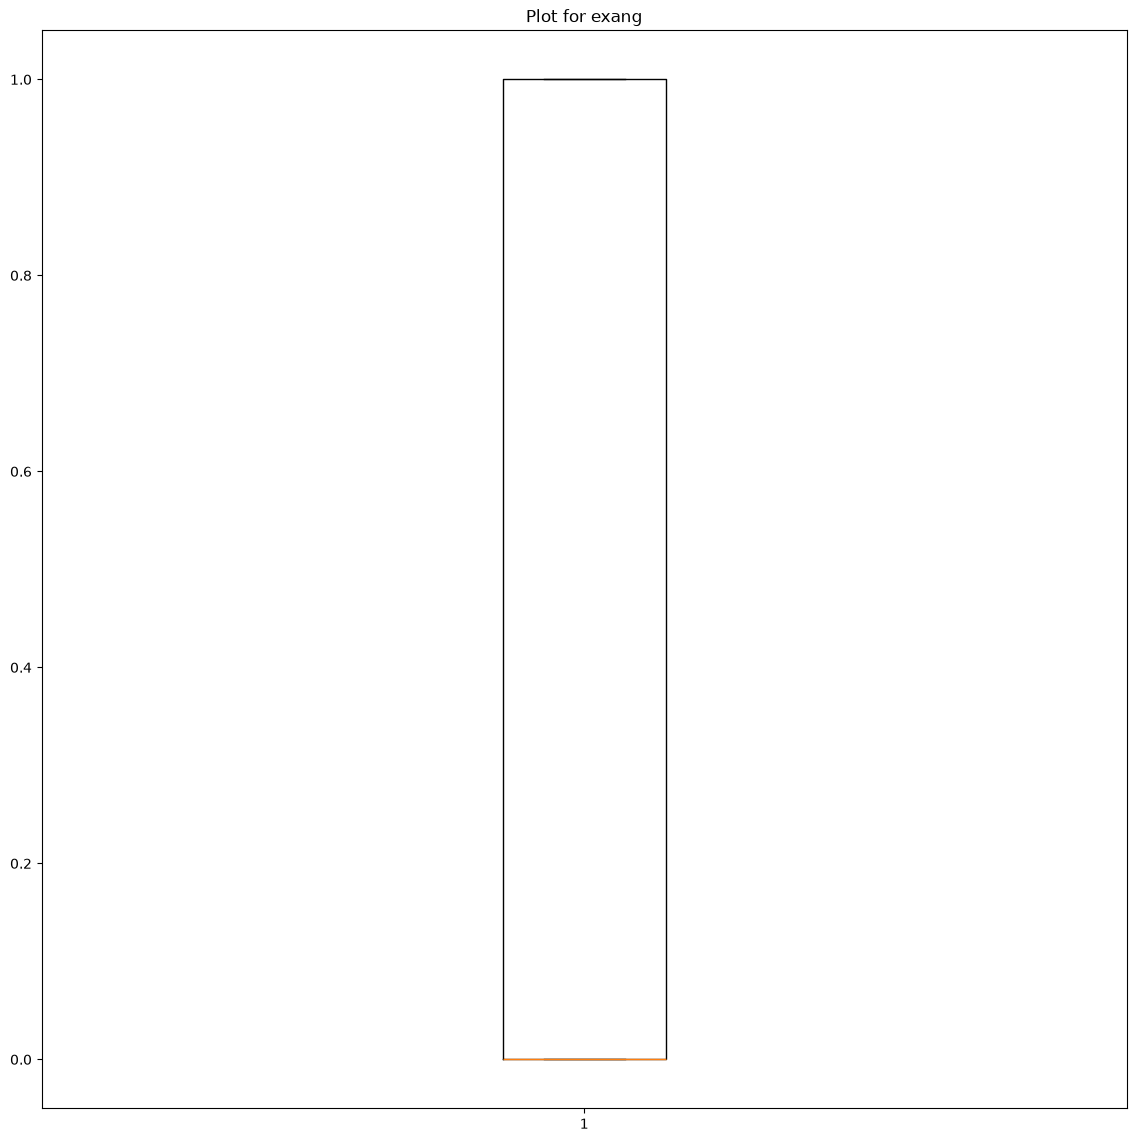

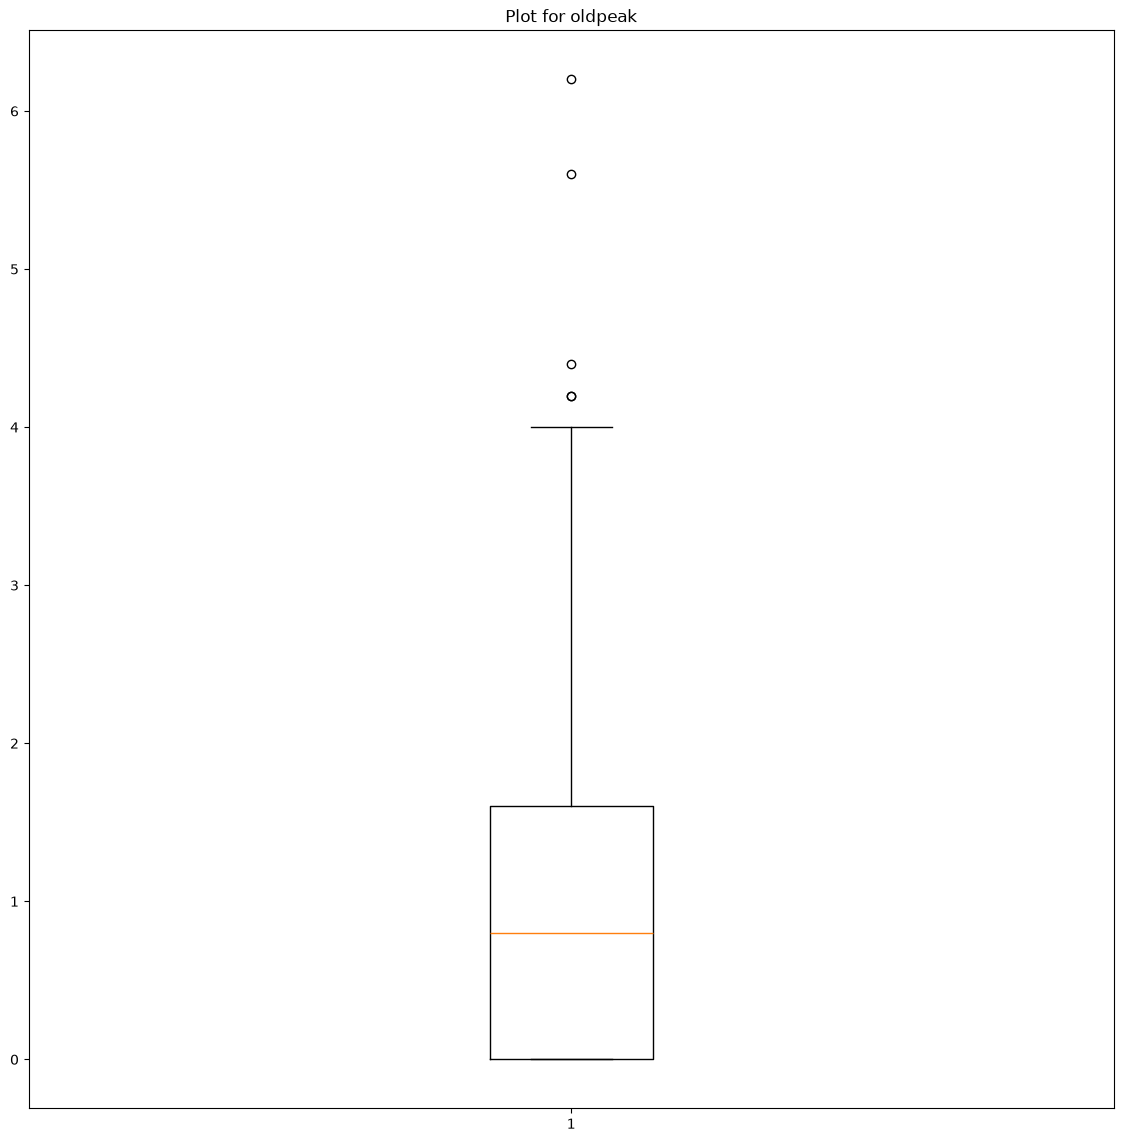

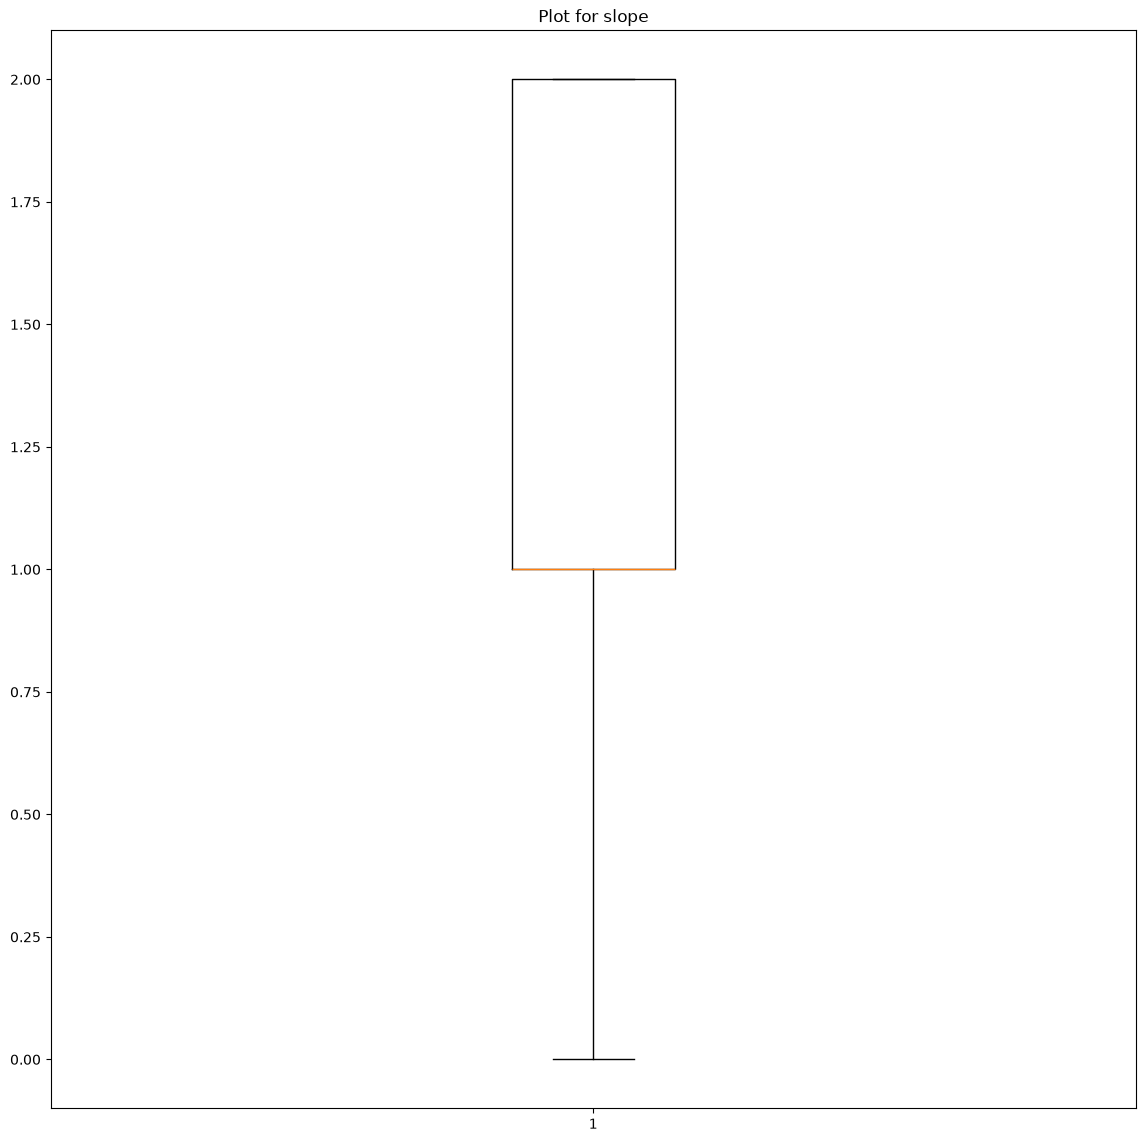

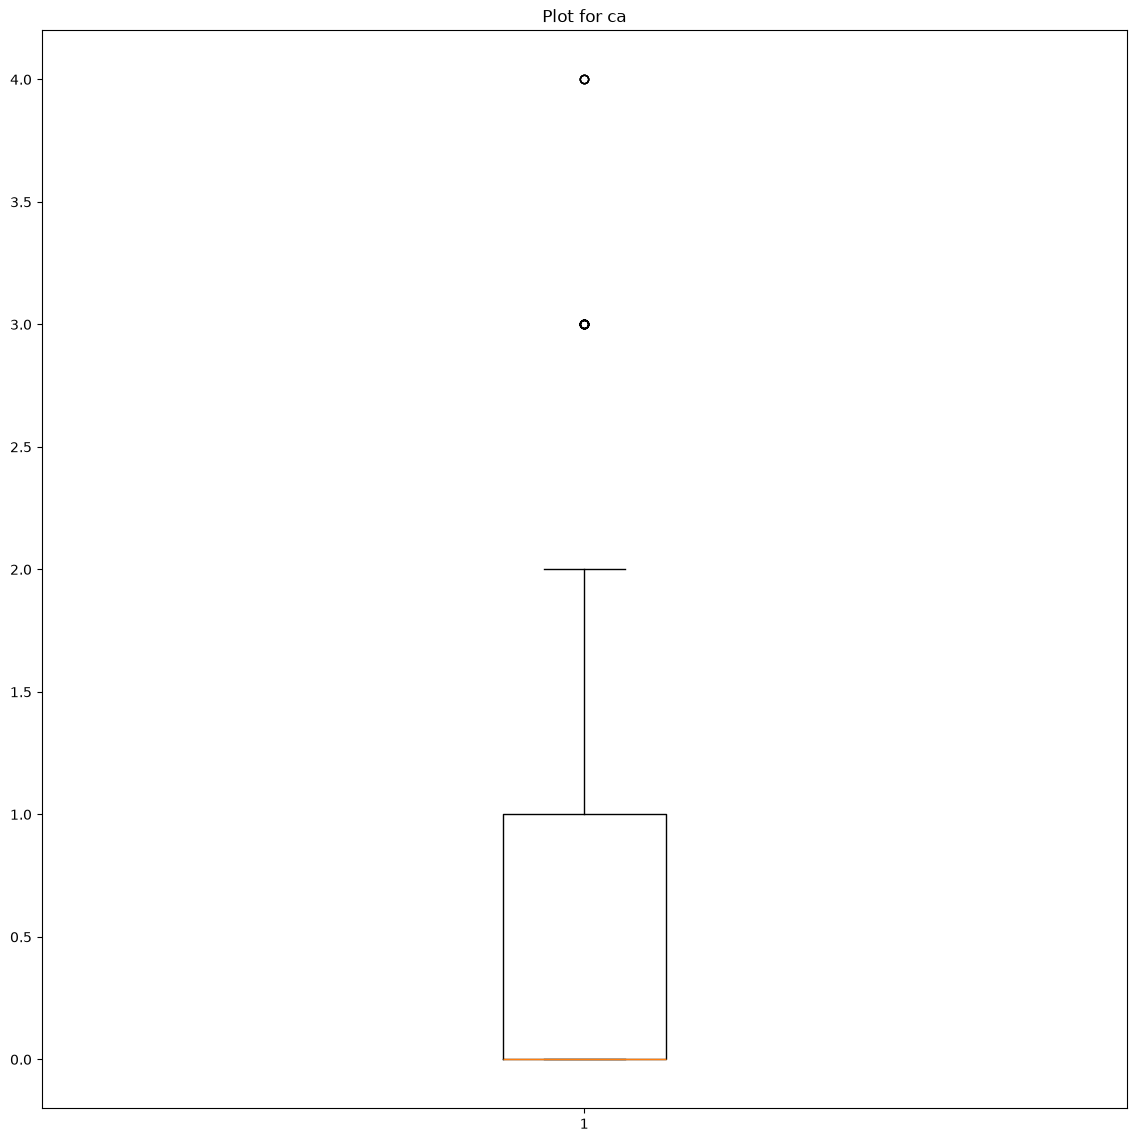

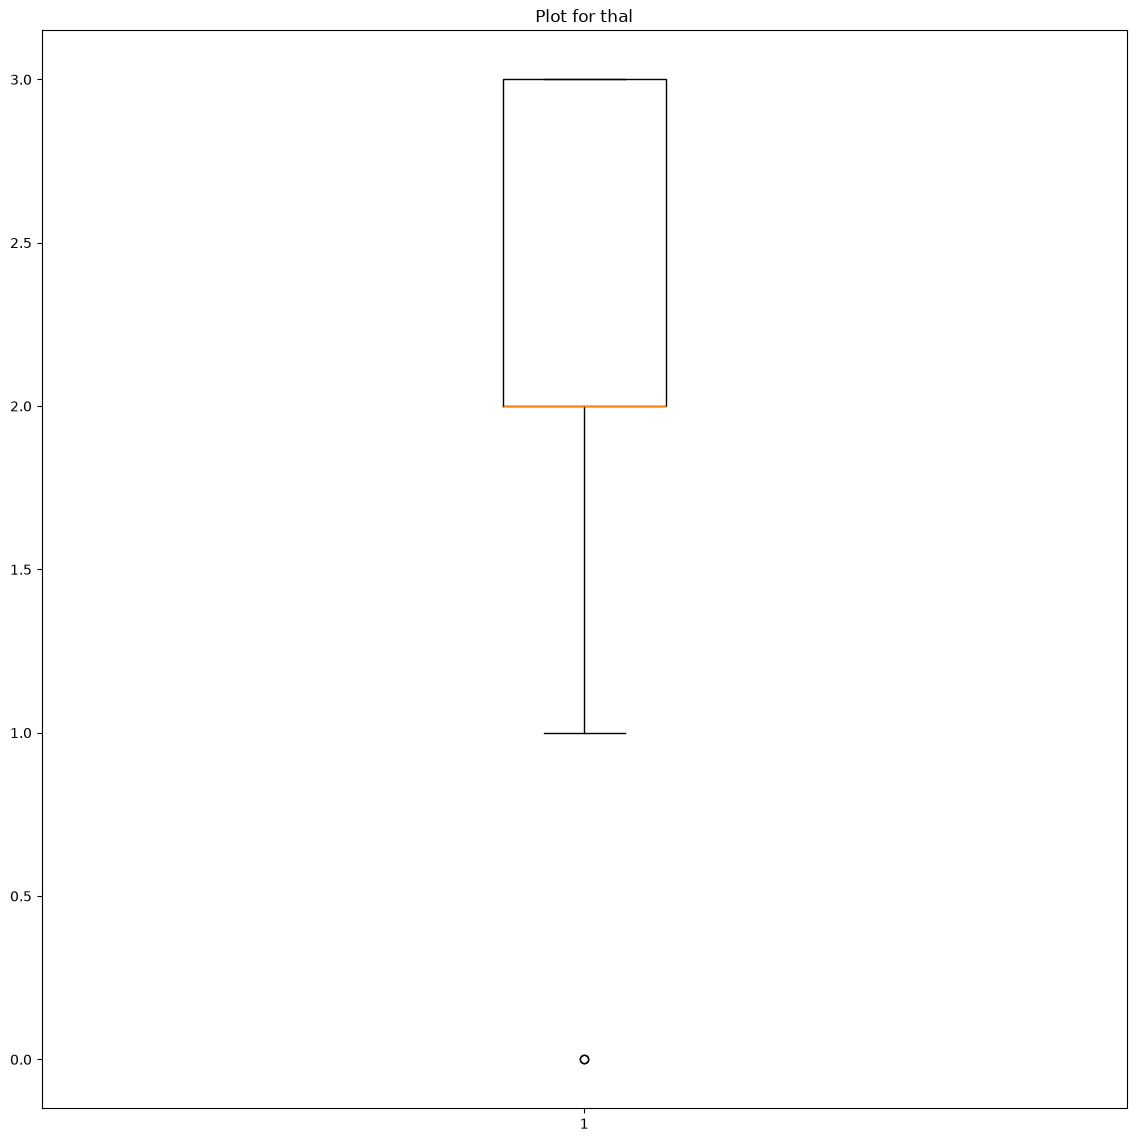

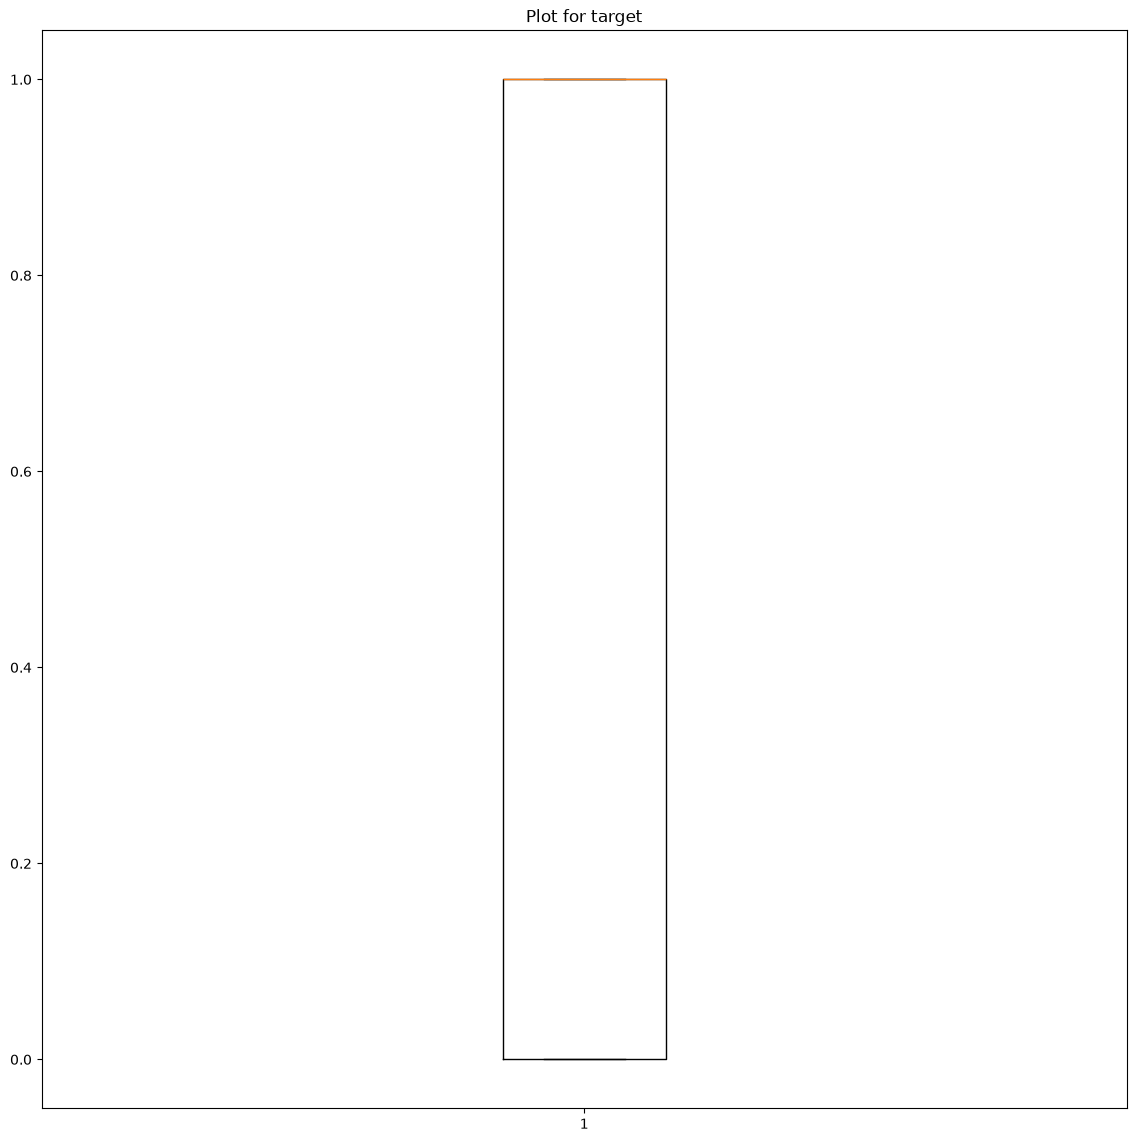

In [131]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=FIGURE_SIZE)

    plt.boxplot(x=df[col])

    plt.title(f"Plot for {col}")
    plt.show()

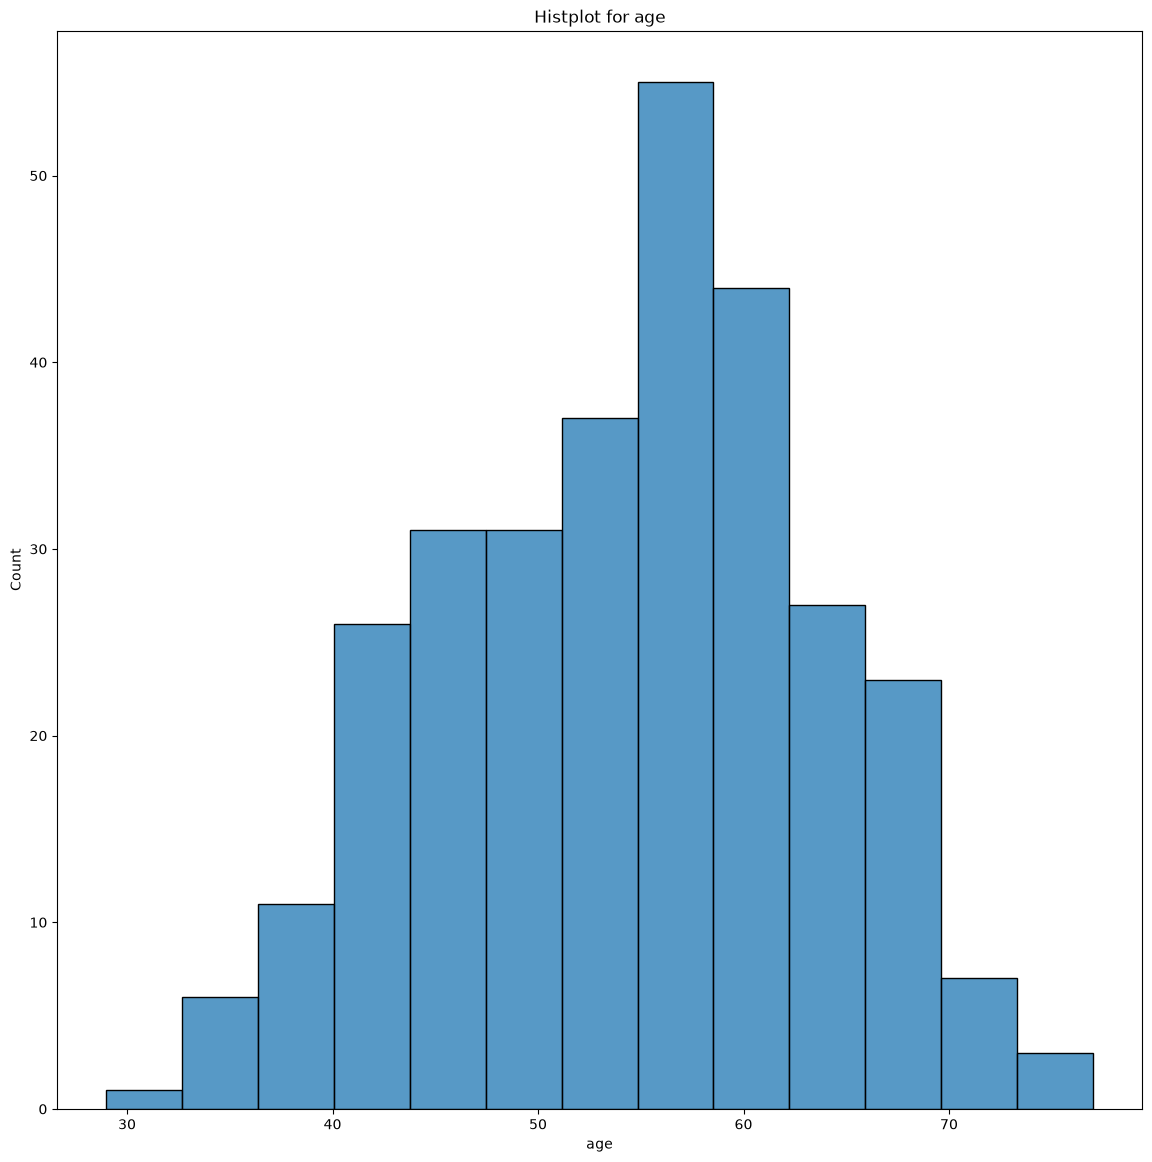

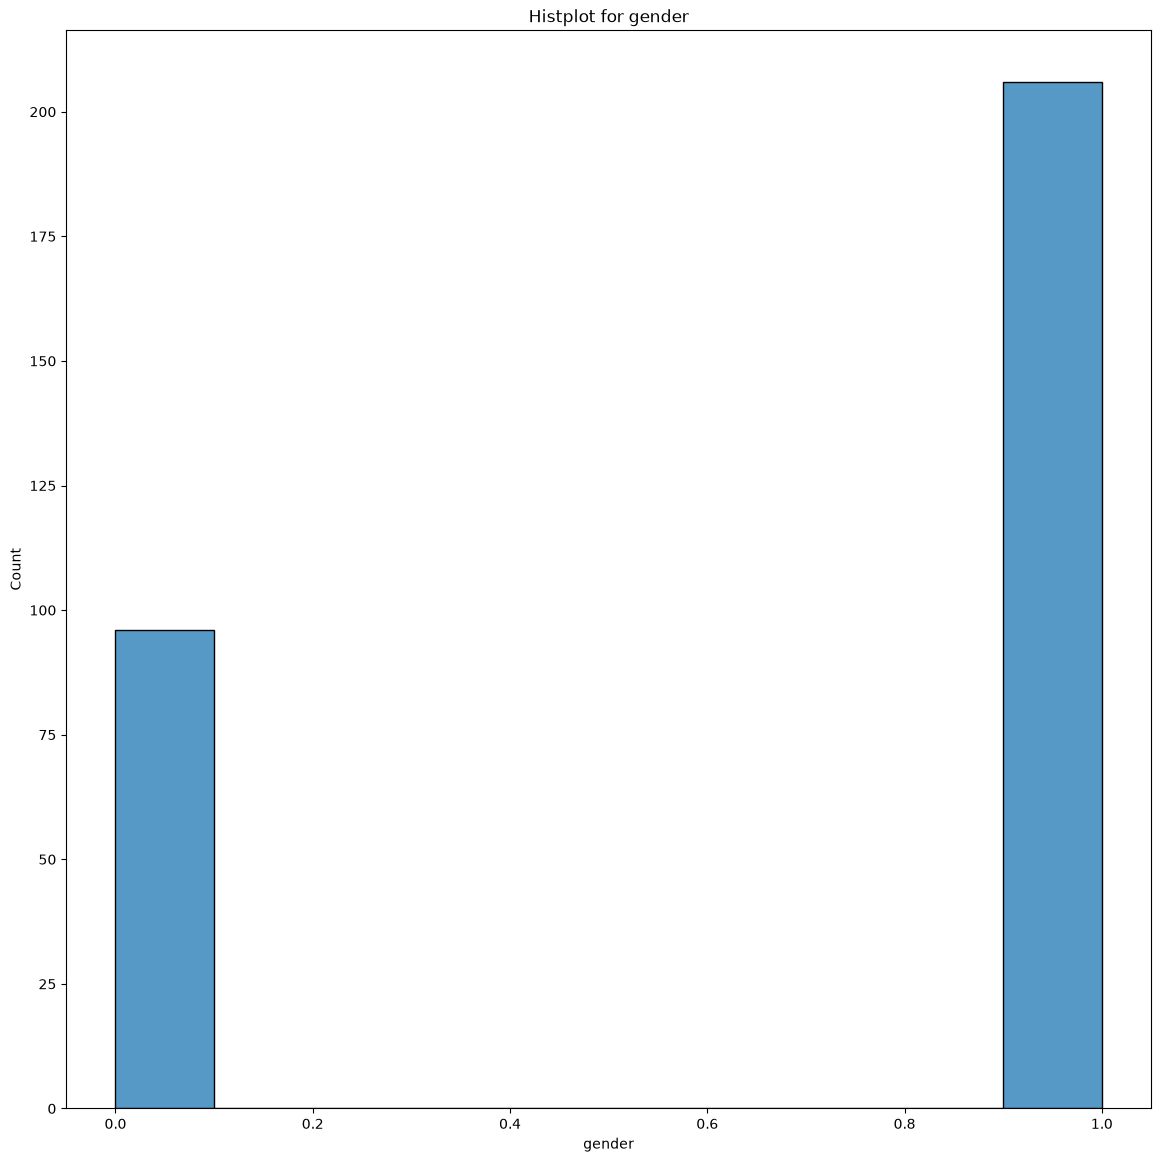

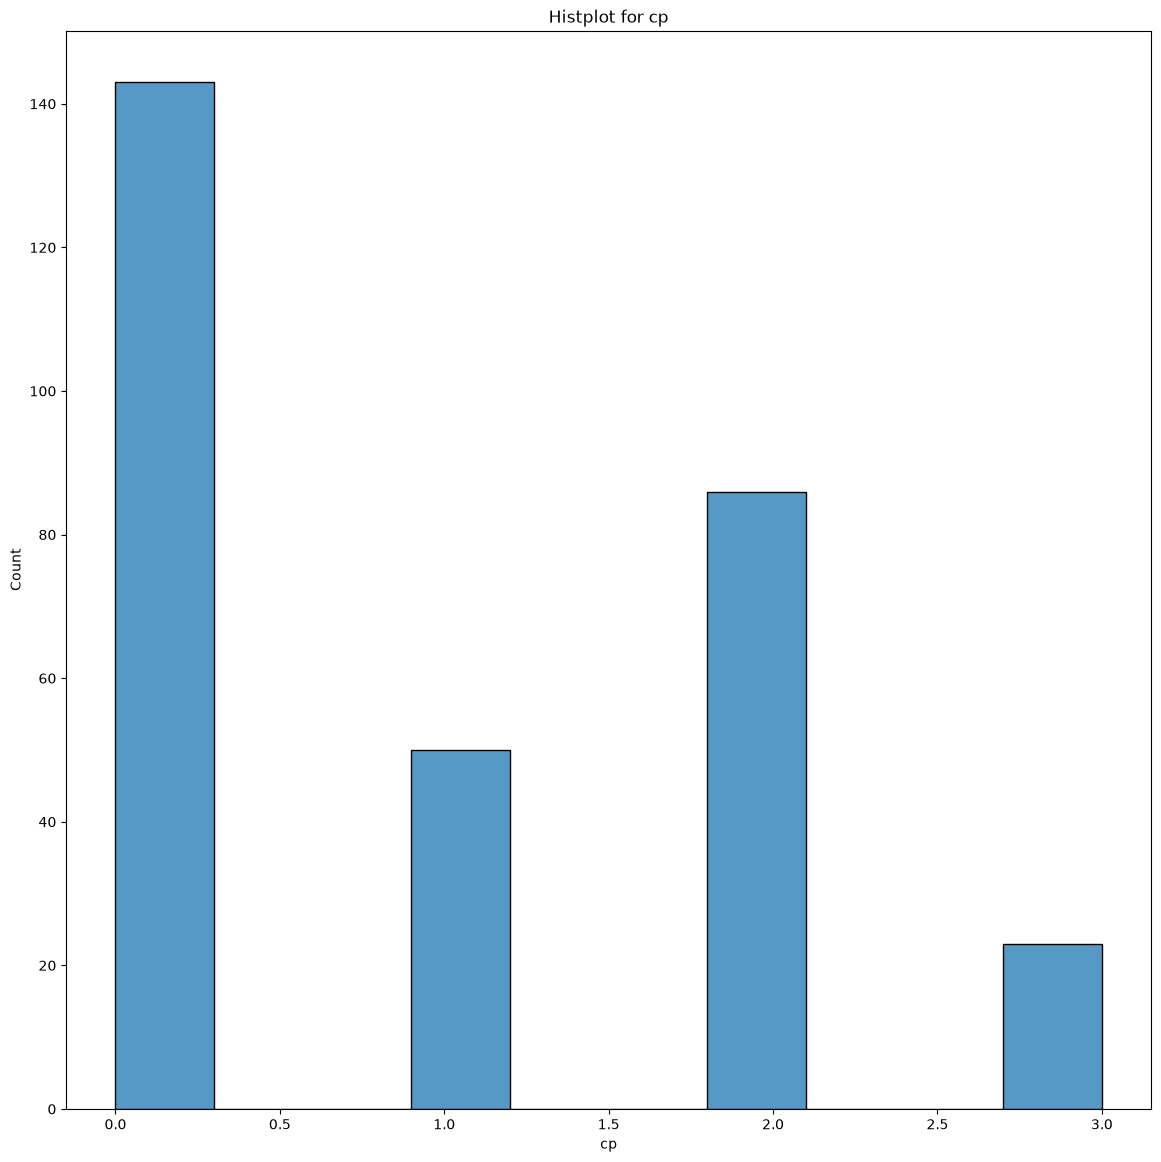

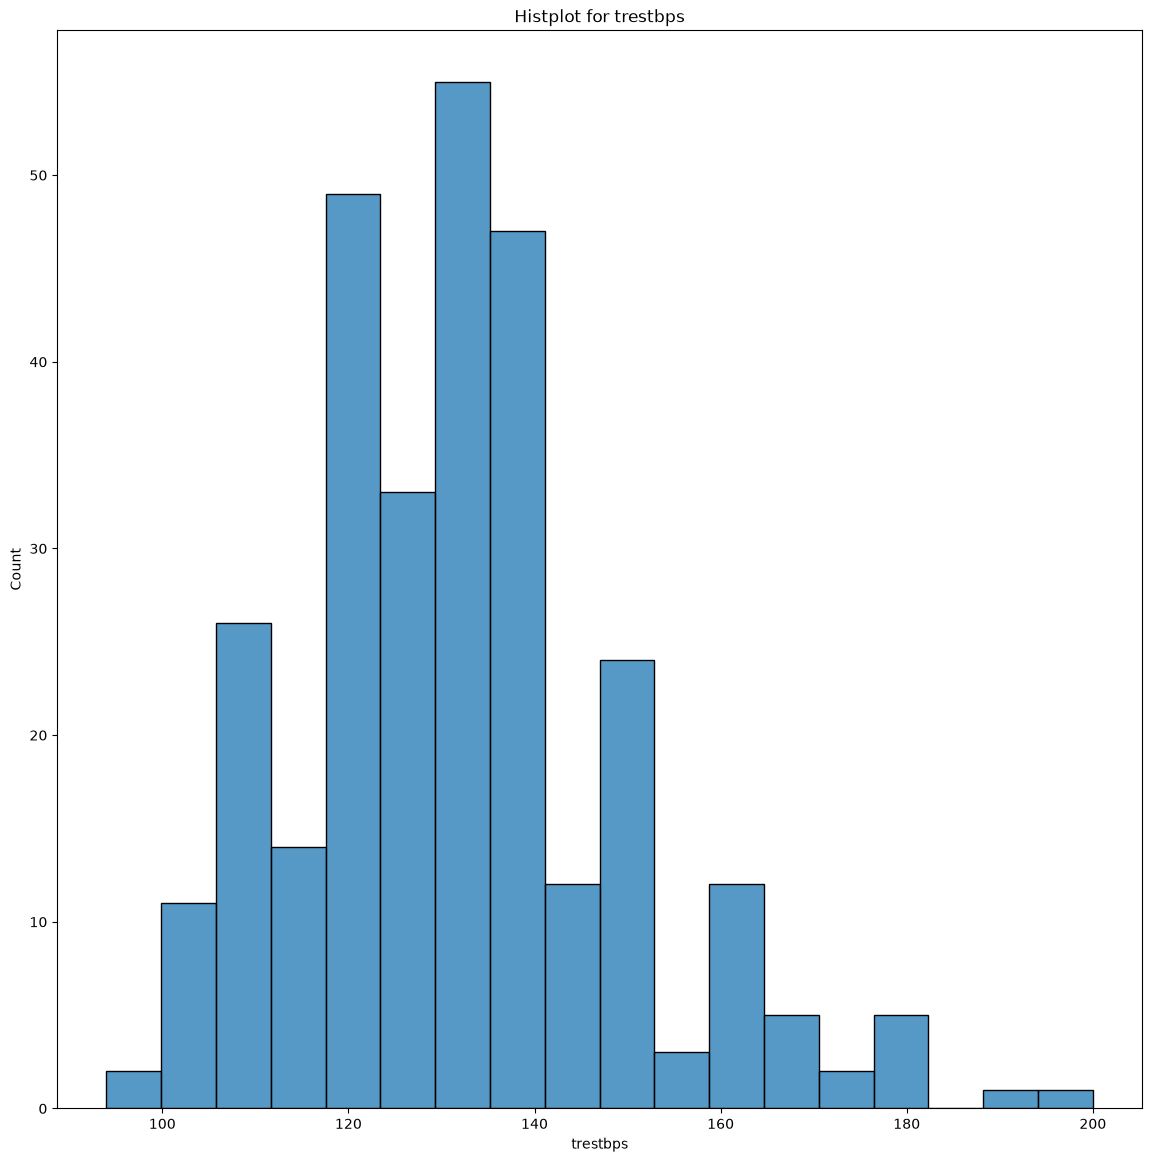

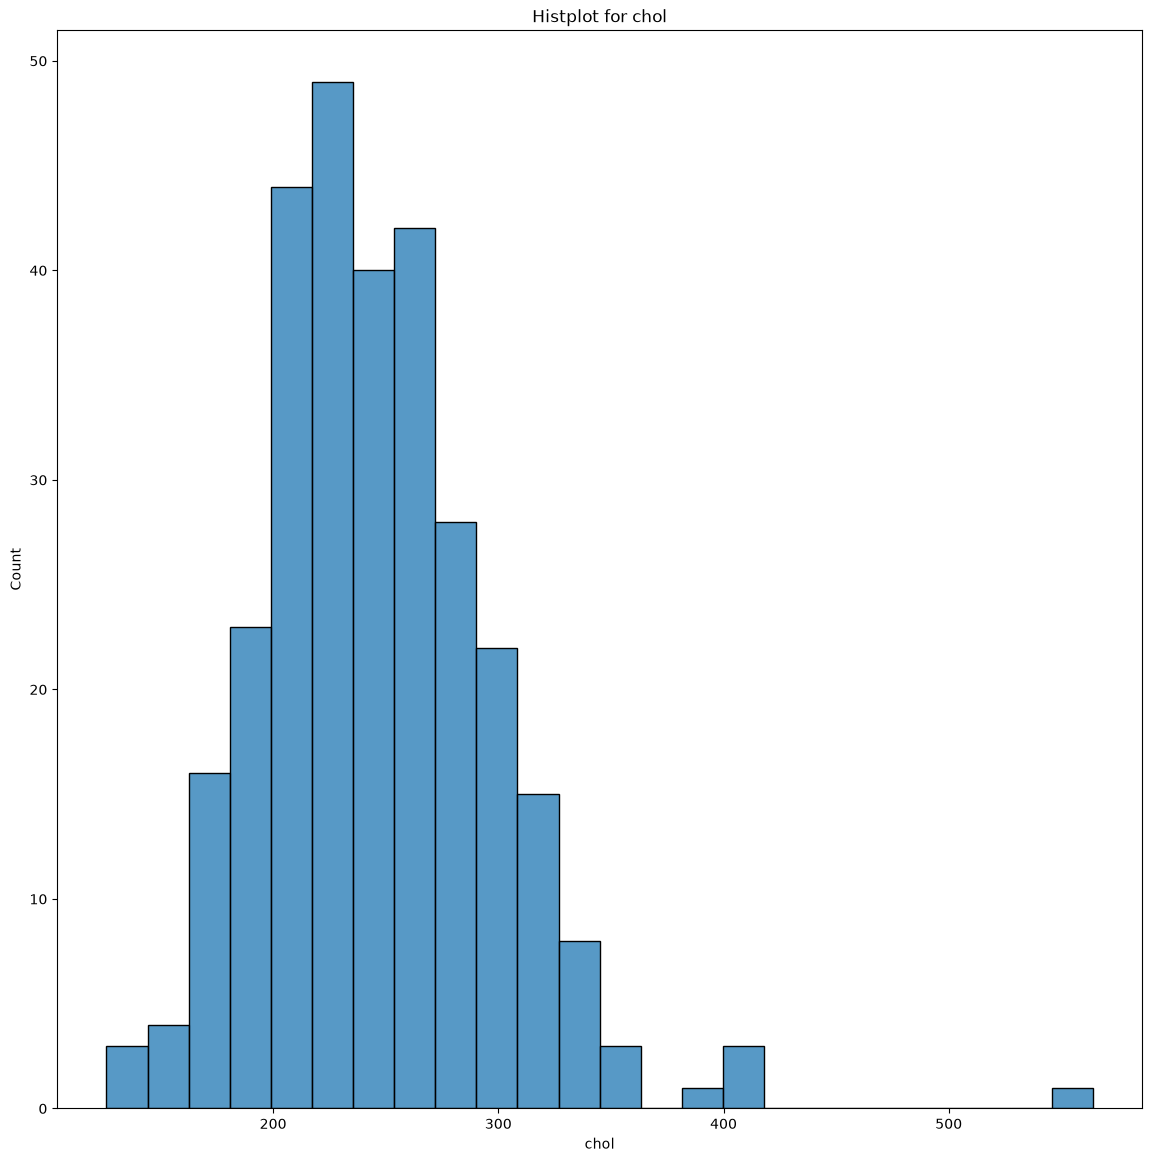

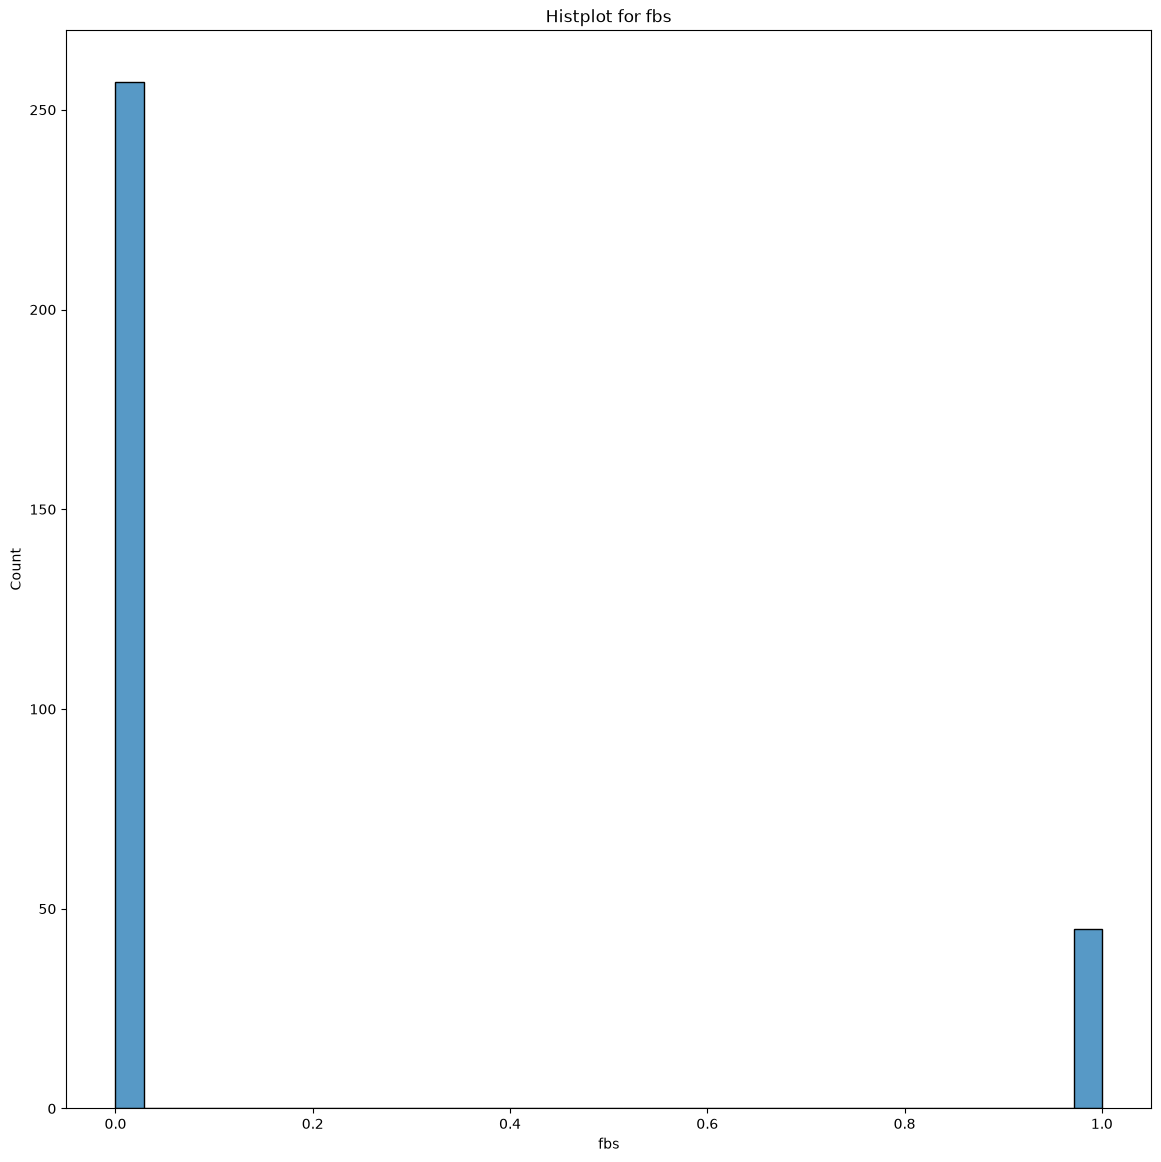

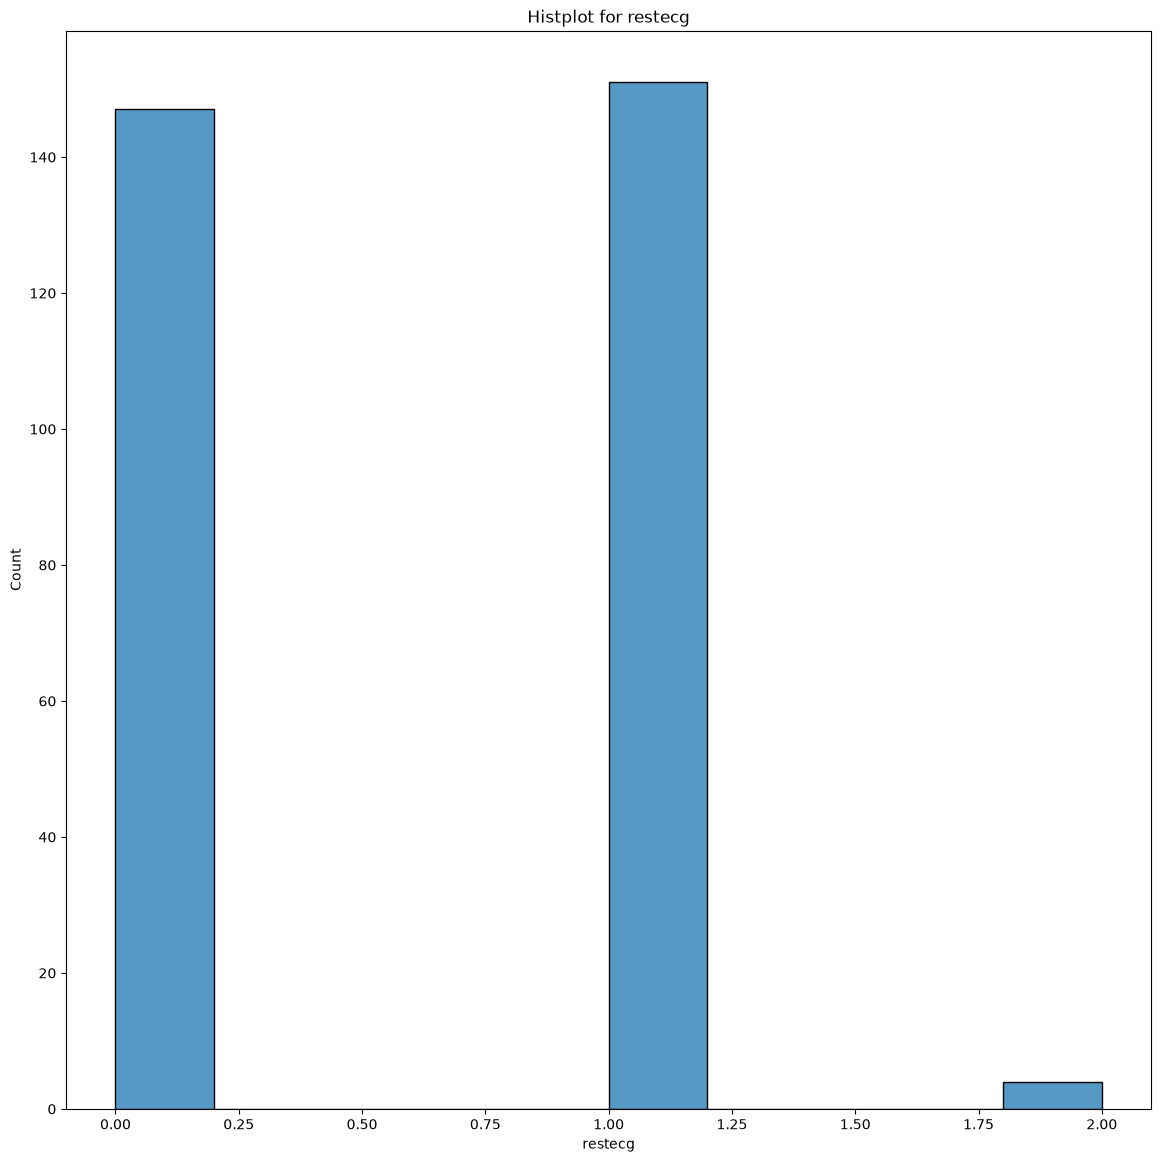

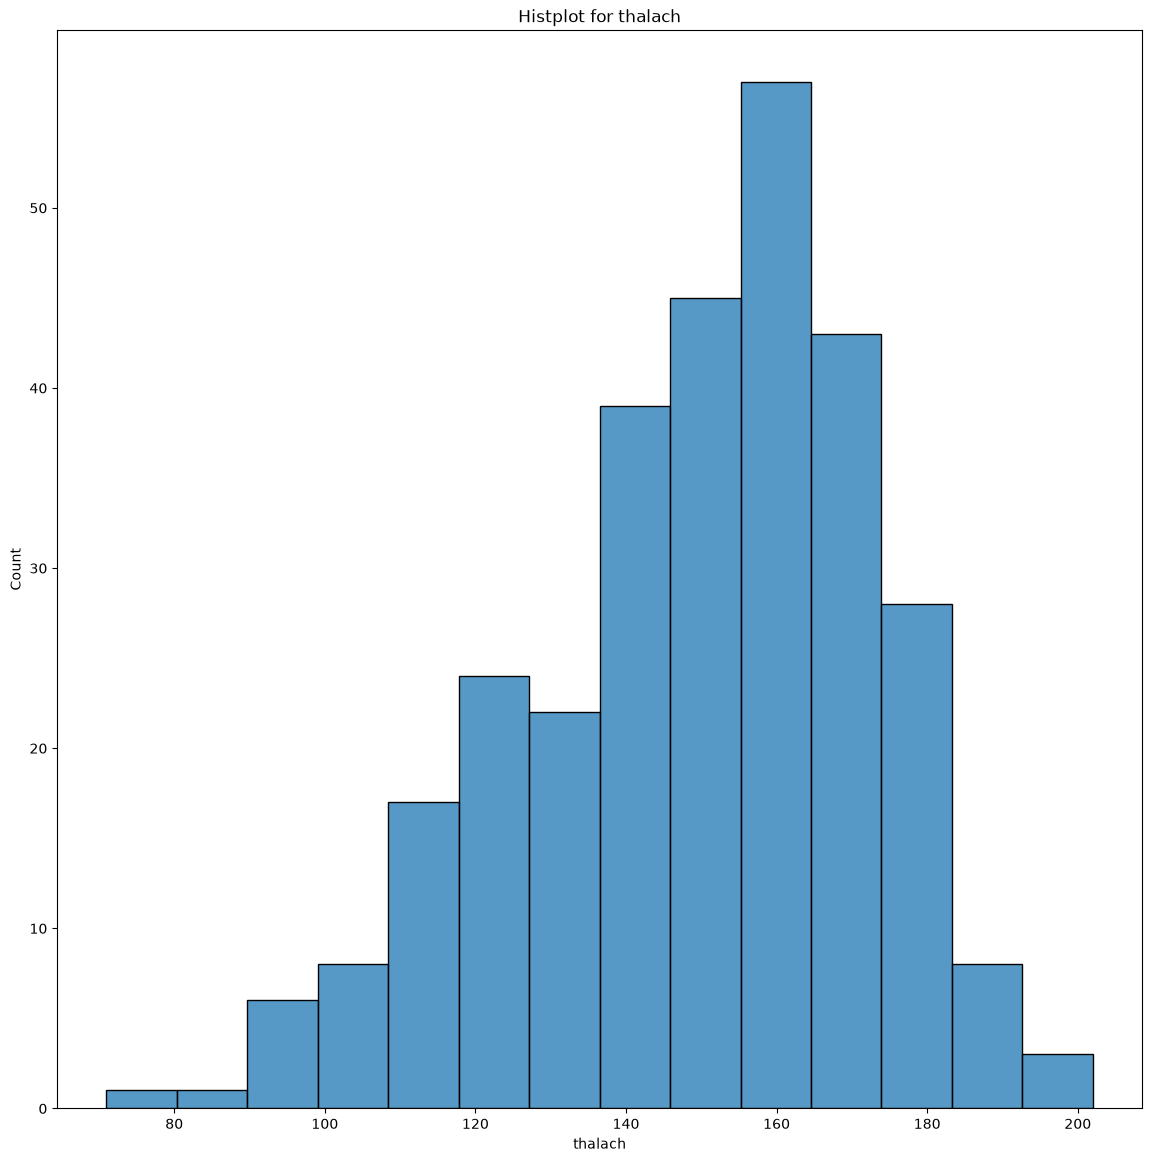

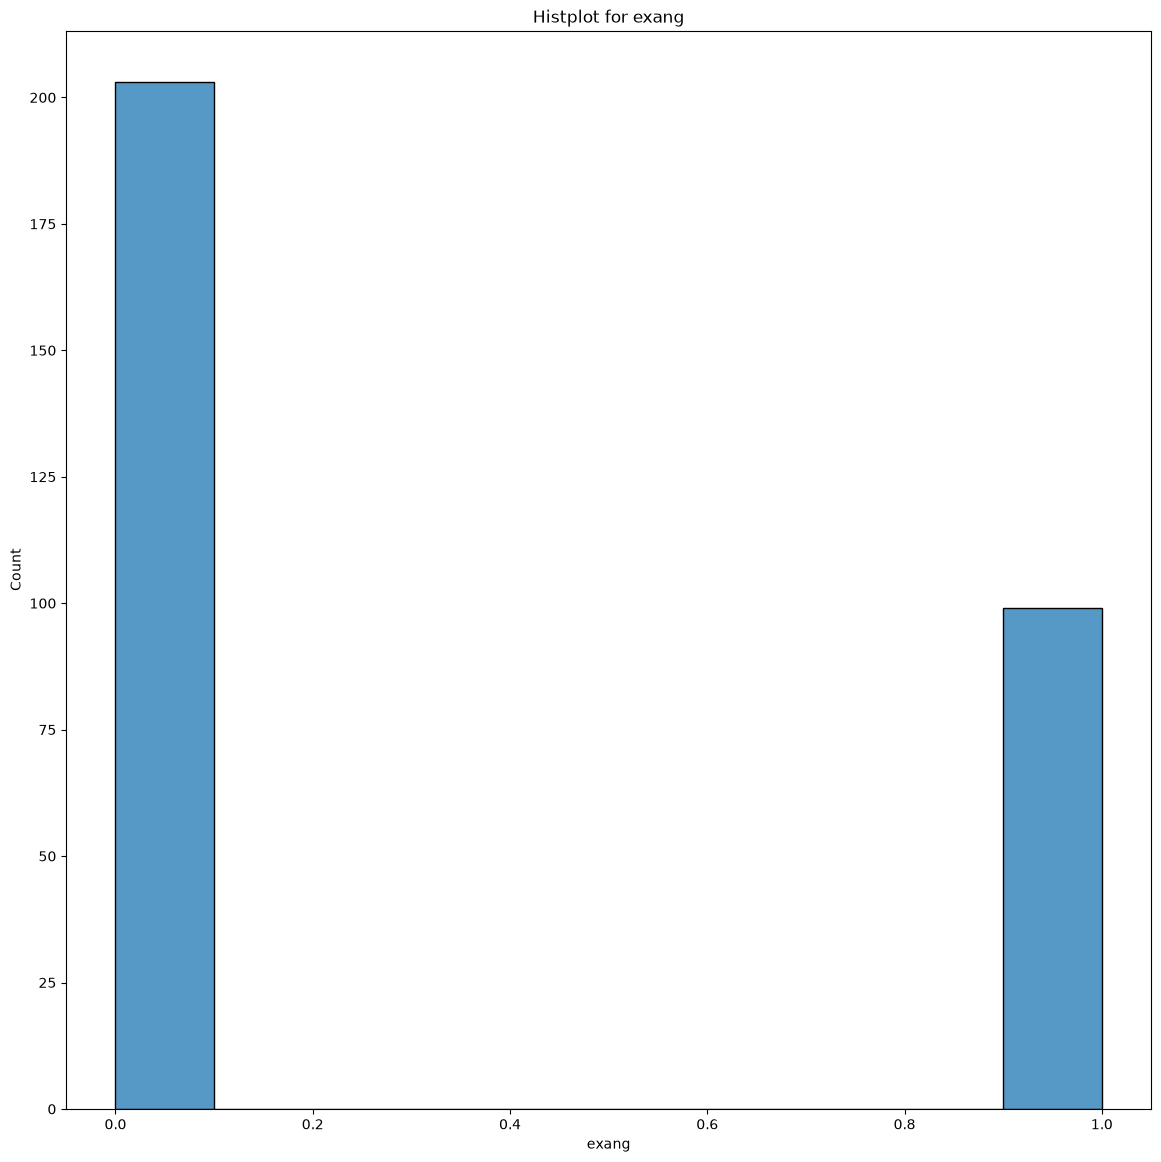

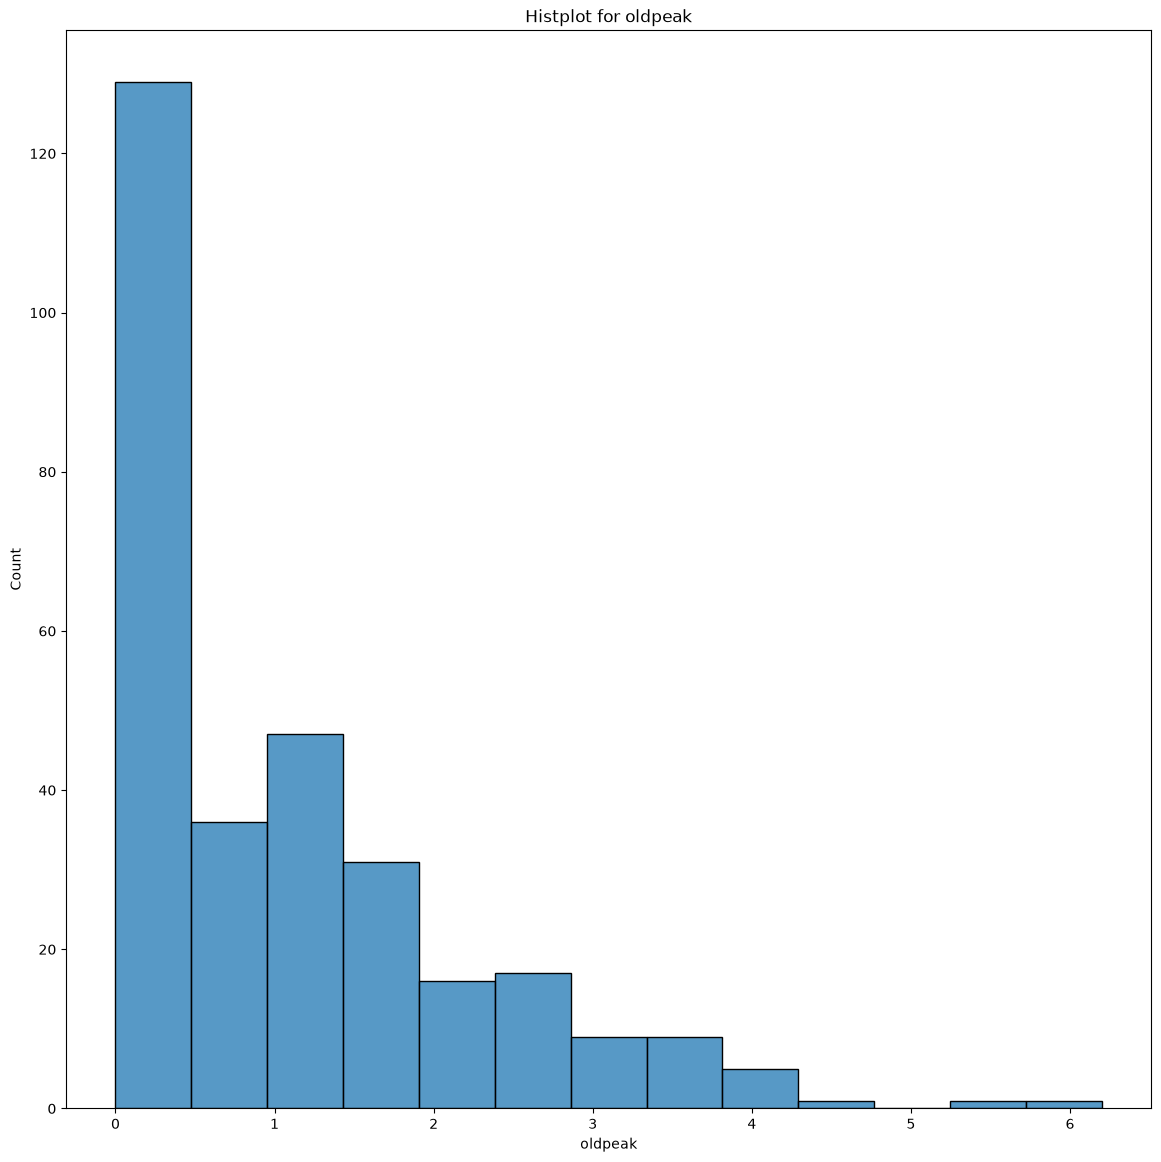

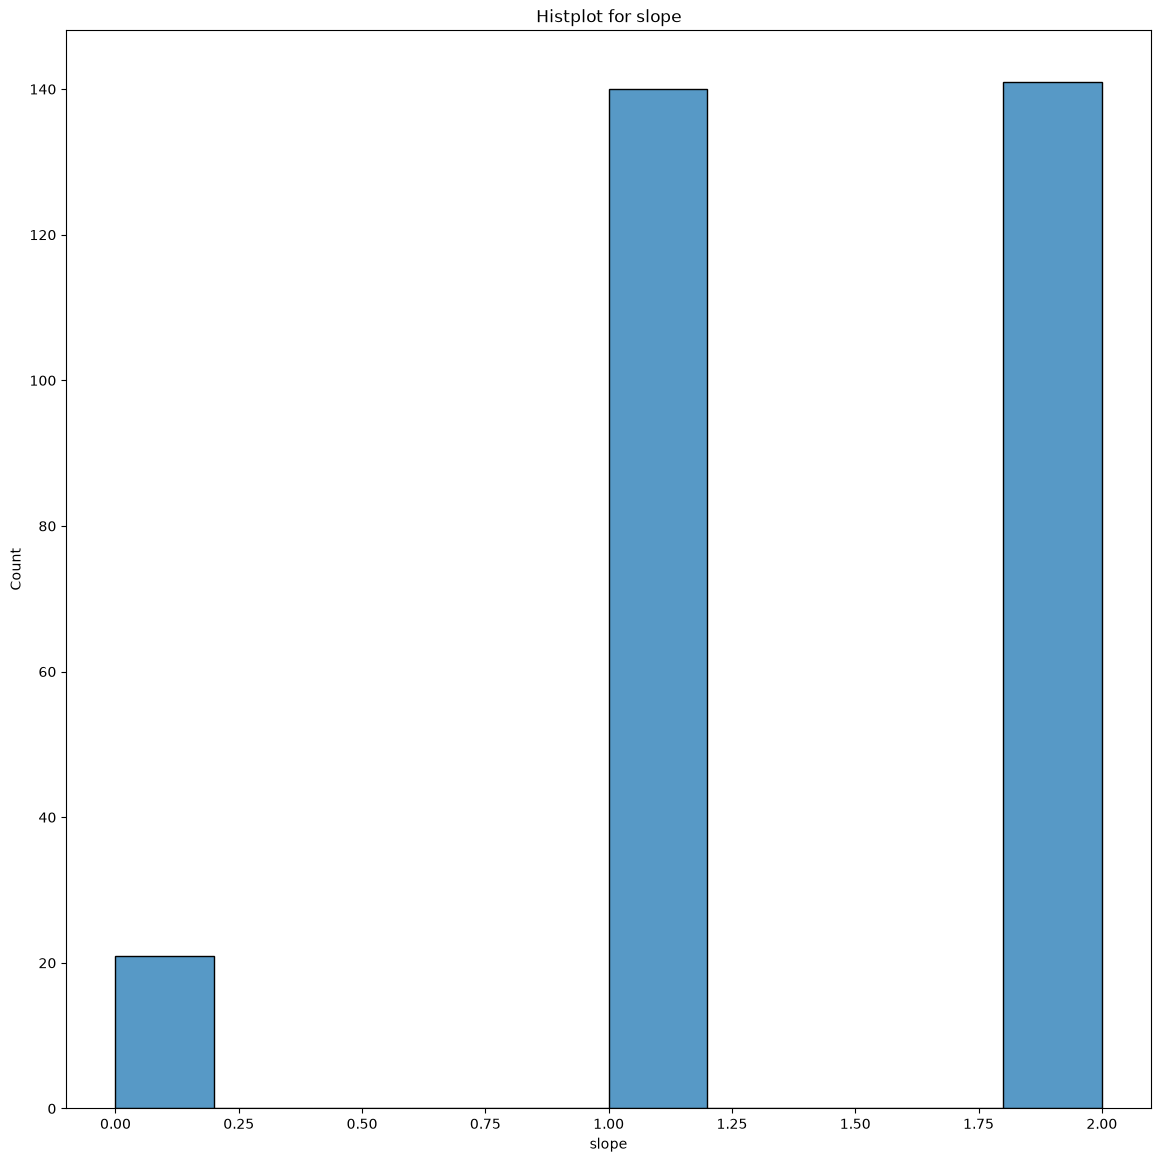

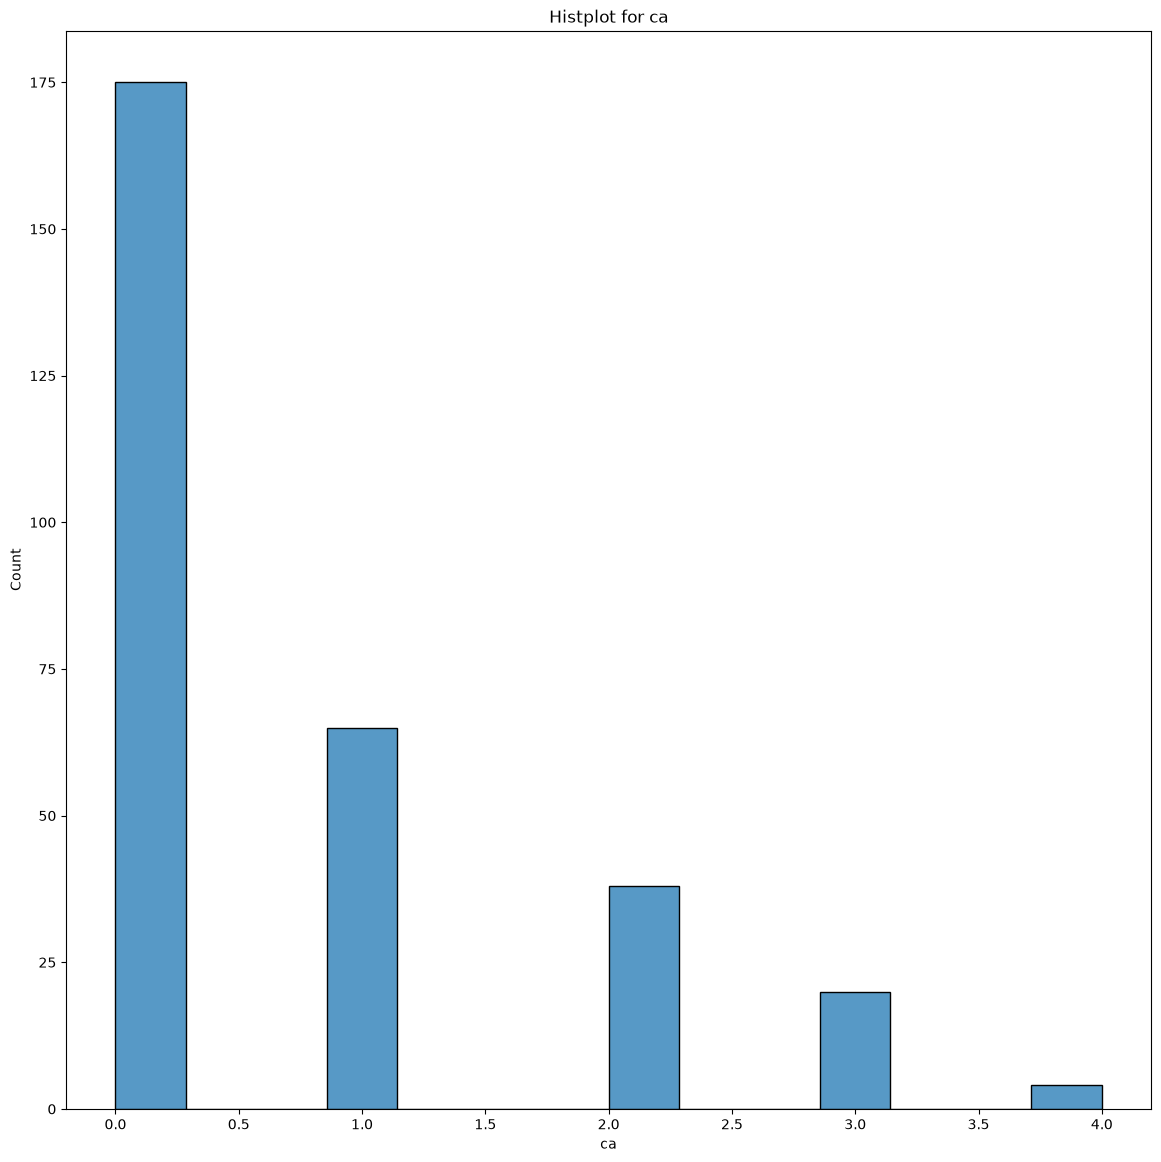

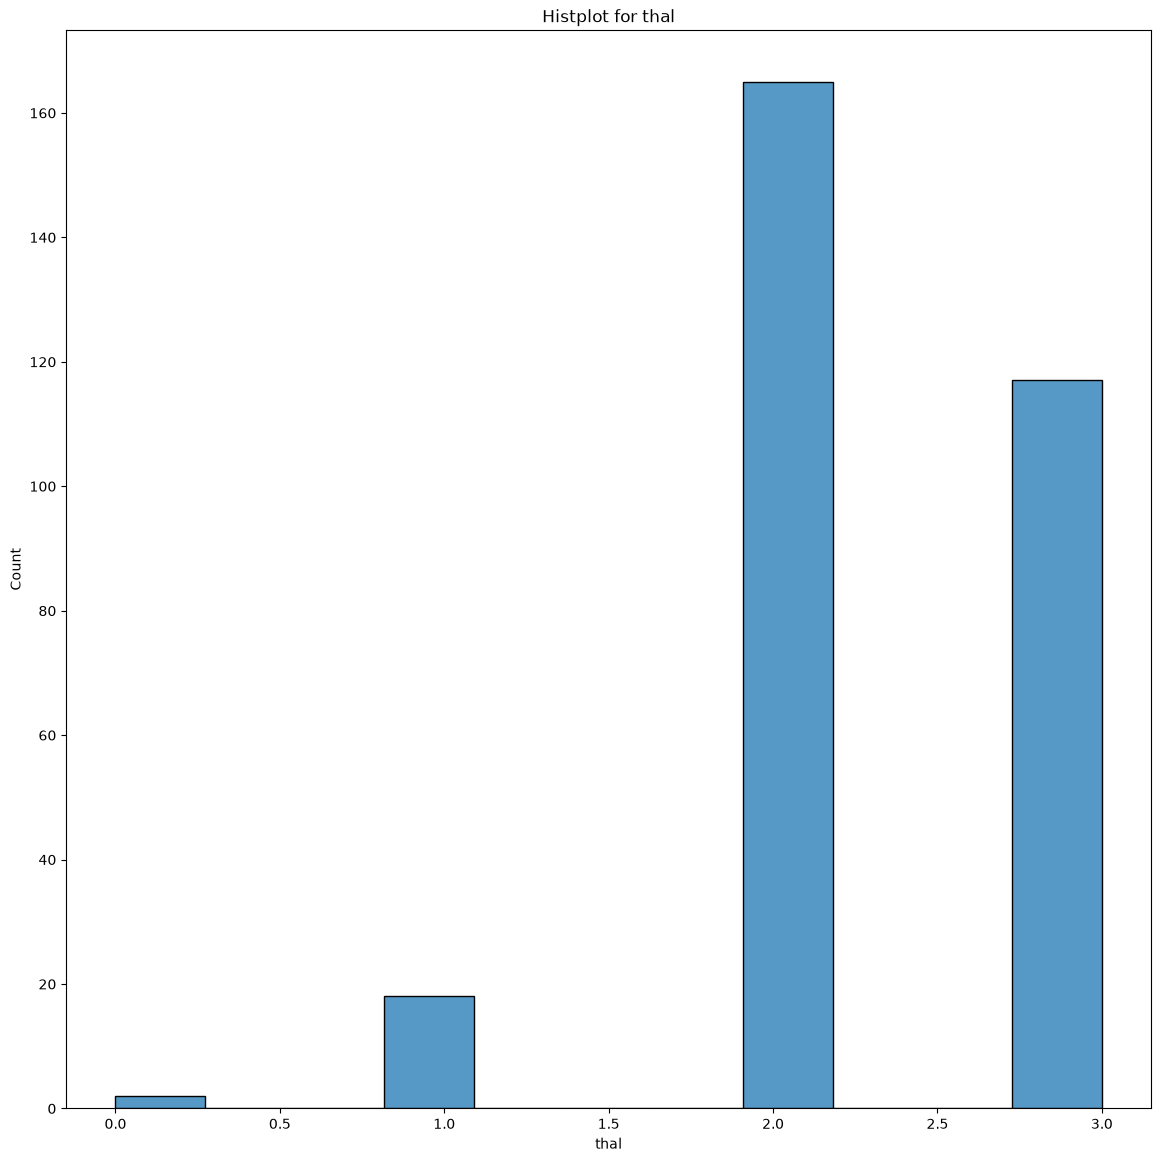

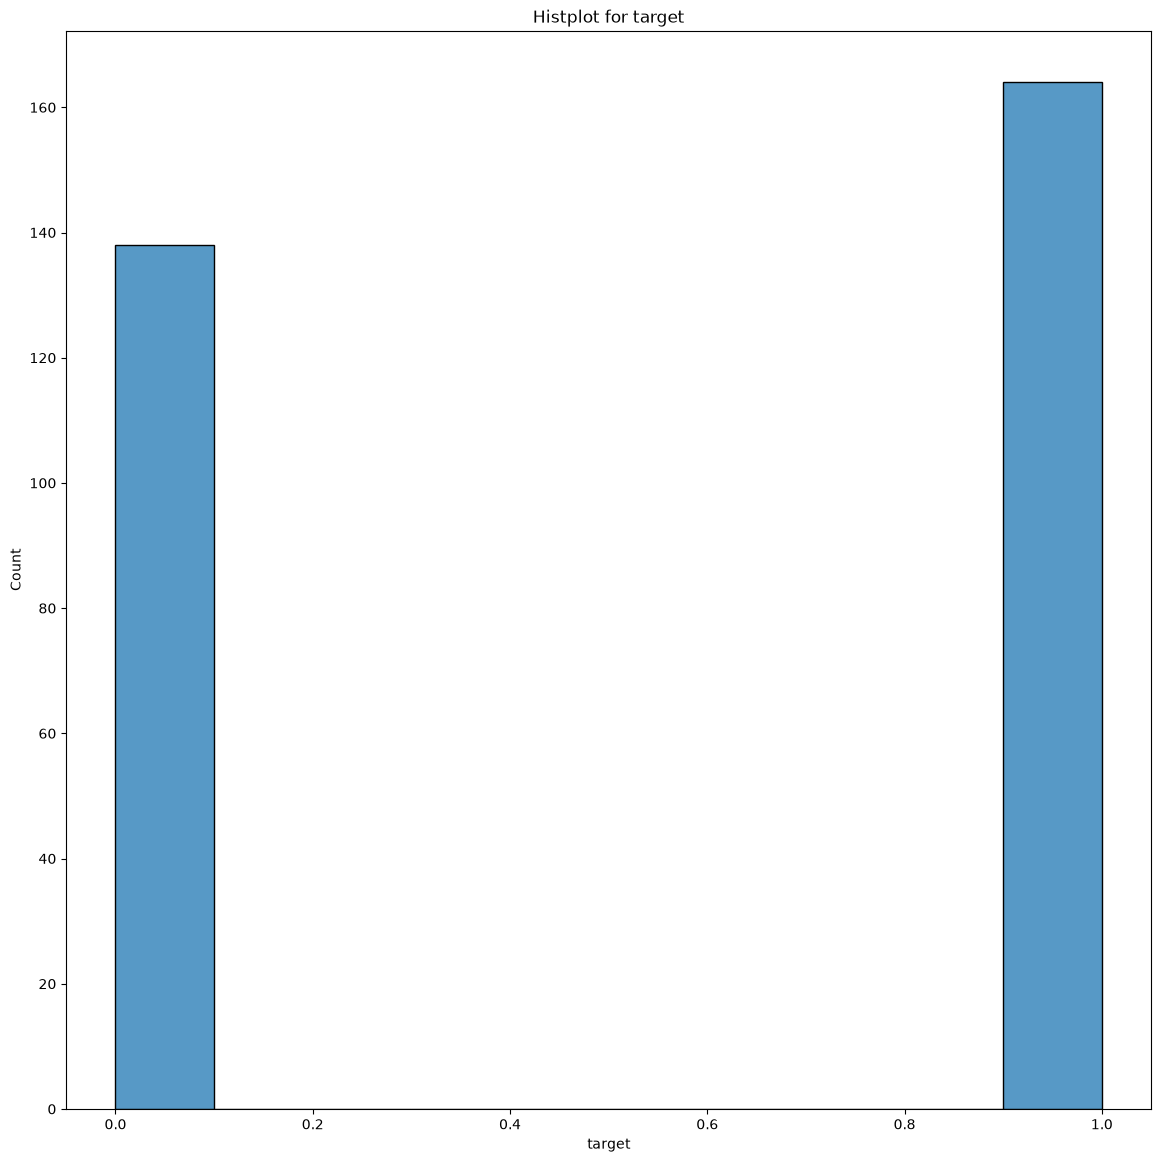

In [132]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=FIGURE_SIZE)

    sns.histplot(df[col])

    plt.title(f"Histplot for {col}")
    plt.show()

The distribution is a bit skewed so IQR analysis is done to check the number of outliers and to examine whether outliers needs to be handled or not

#### IQR analysis

In [133]:
iqr_counts = {}

for col in NUMERICAL_COLUMNS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    iqr_counts[col] = int(((df[col] < lower_limit) | (df[col] > upper_limit)).sum())

pd.DataFrame({ "IQR counts": iqr_counts })

,IQR counts
age,0
gender,0
cp,0
trestbps,9
chol,5
fbs,45
restecg,0
thalach,1
exang,0
oldpeak,5


Based on all the information gained the outliers are more-of numerical outliers but are values that can be logically present. Hence keeping the outliers as it is and not handling them

## 8. Correlation Analysis

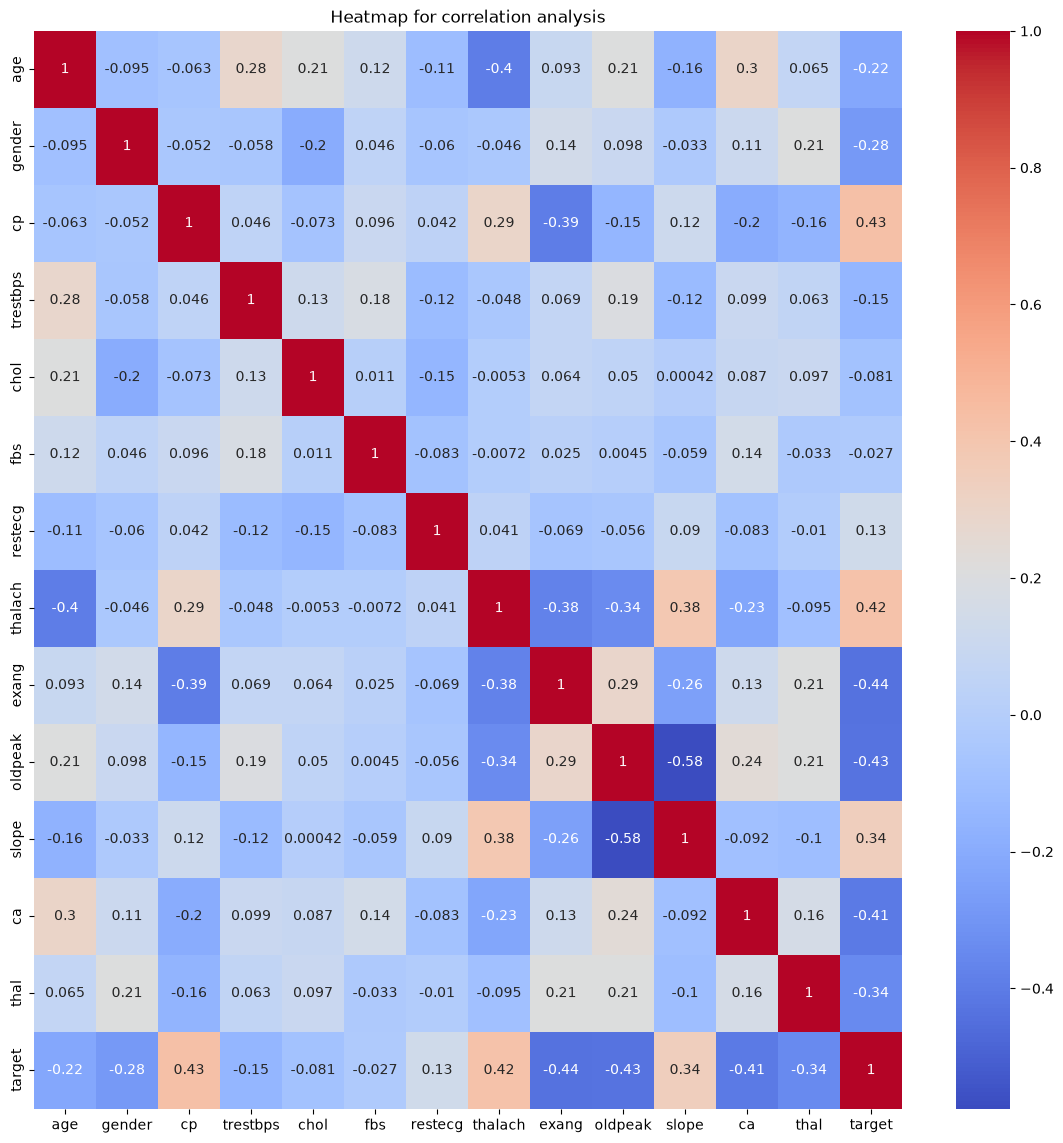

In [134]:
plot_correlation_heatmap(df, NUMERICAL_COLUMNS)

There are many subtle positive and negative relations but there are no proper relevant relations that can be observed, this means that the dataset is highly balanced which can suggest that it is a synthetically generated dataset

#### Preprocessing decisions

✓ Will apply scaling

Reason:
the model being used is a distance based classification algorithm so scaling is preferred to make the predictions better

## 9. Preparing the data for model training

In [135]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


## 10. Scaling the split data

In [137]:
X_train = SCALER.fit_transform(X_train)

In [138]:
X_test = SCALER.transform(X_test)

## 11. Fitting the Scaled data in the model 

In [139]:
svc_model = SVC(**SVC_PARAMS)

In [140]:
svc_model.fit(X_train, y_train)

C:\Users\tusha\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


## 12. Evaluating the model metrics

In [143]:
evaluate_model(svc_model, X_test, y_test)

Accuracy score:  0.8360655737704918

ROC AUC score:  0.8809523809523809

 Confusion matrix: 
 [[20  8]
 [ 2 31]]

 Classification report: 
               precision    recall  f1-score   support

           0       0.91      0.71      0.80        28
           1       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



## 13. Plot for feature importance

C:\Users\tusha\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


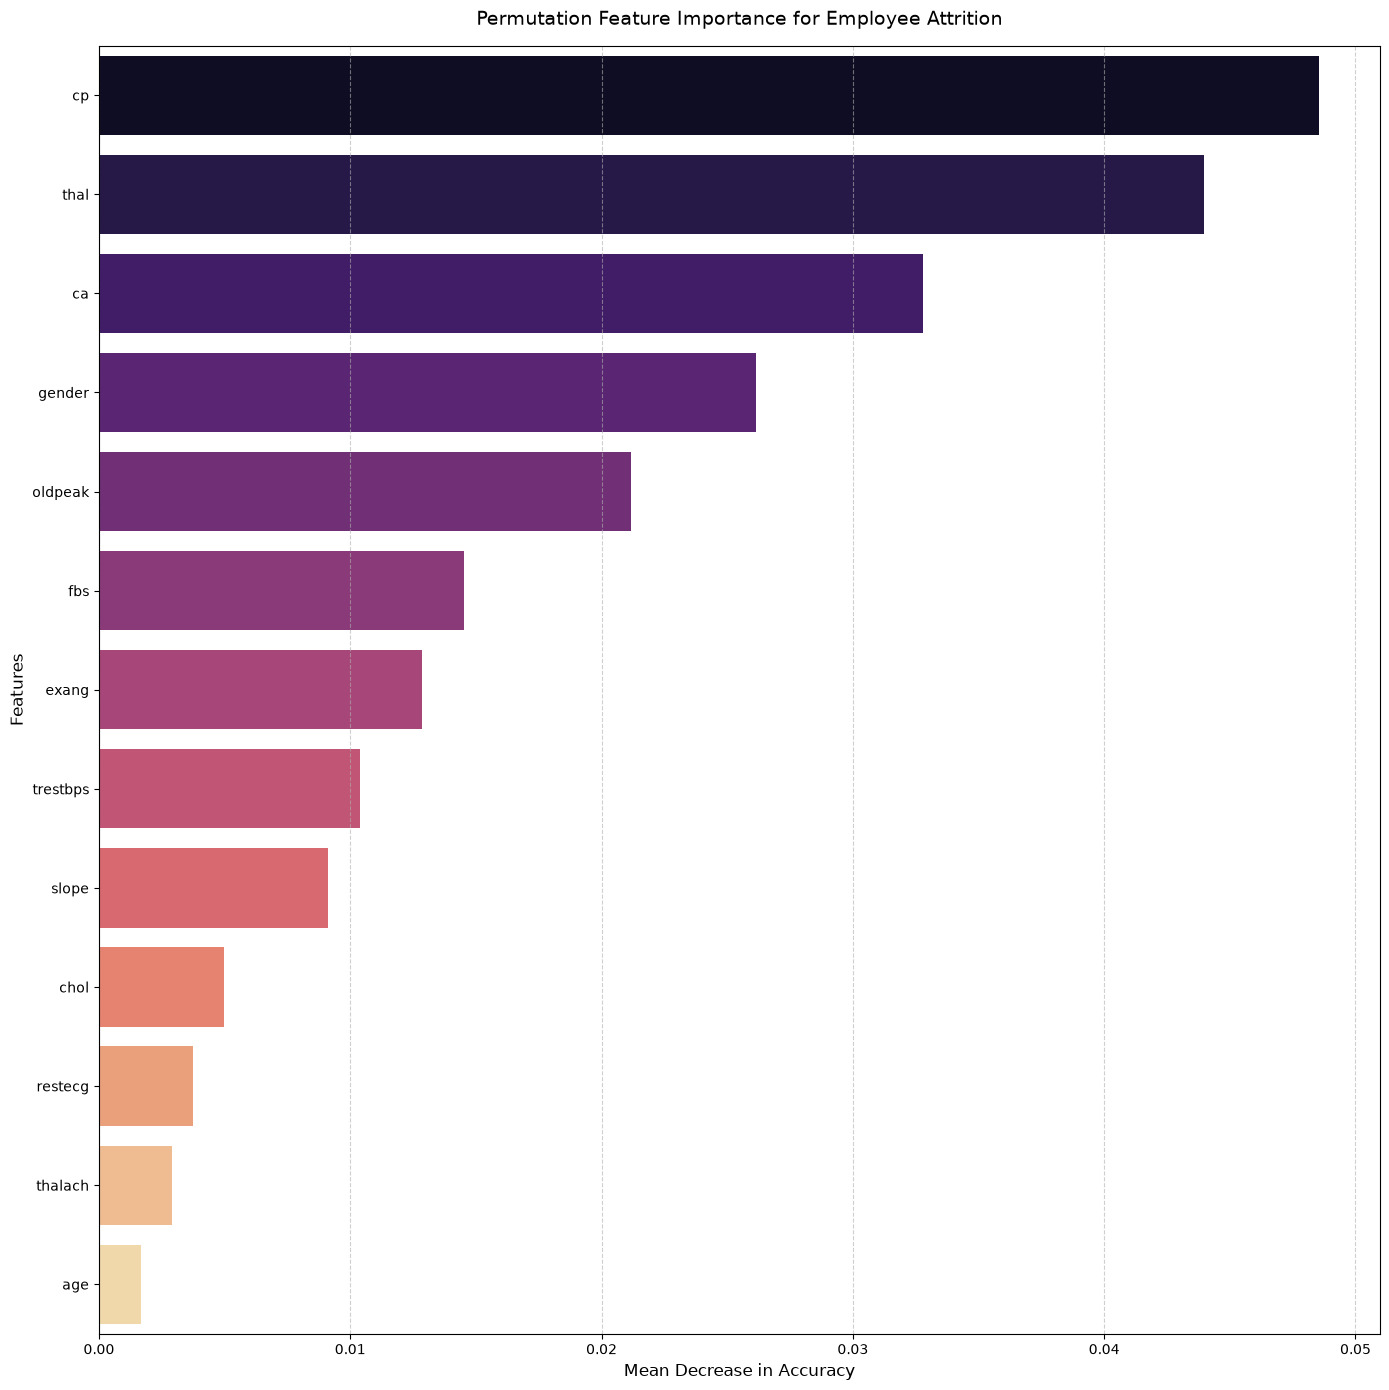

In [154]:
plot_feature_importance(svc_model, X_train, y_train, X.columns)

## 14. Visualization of ROC AUC curve

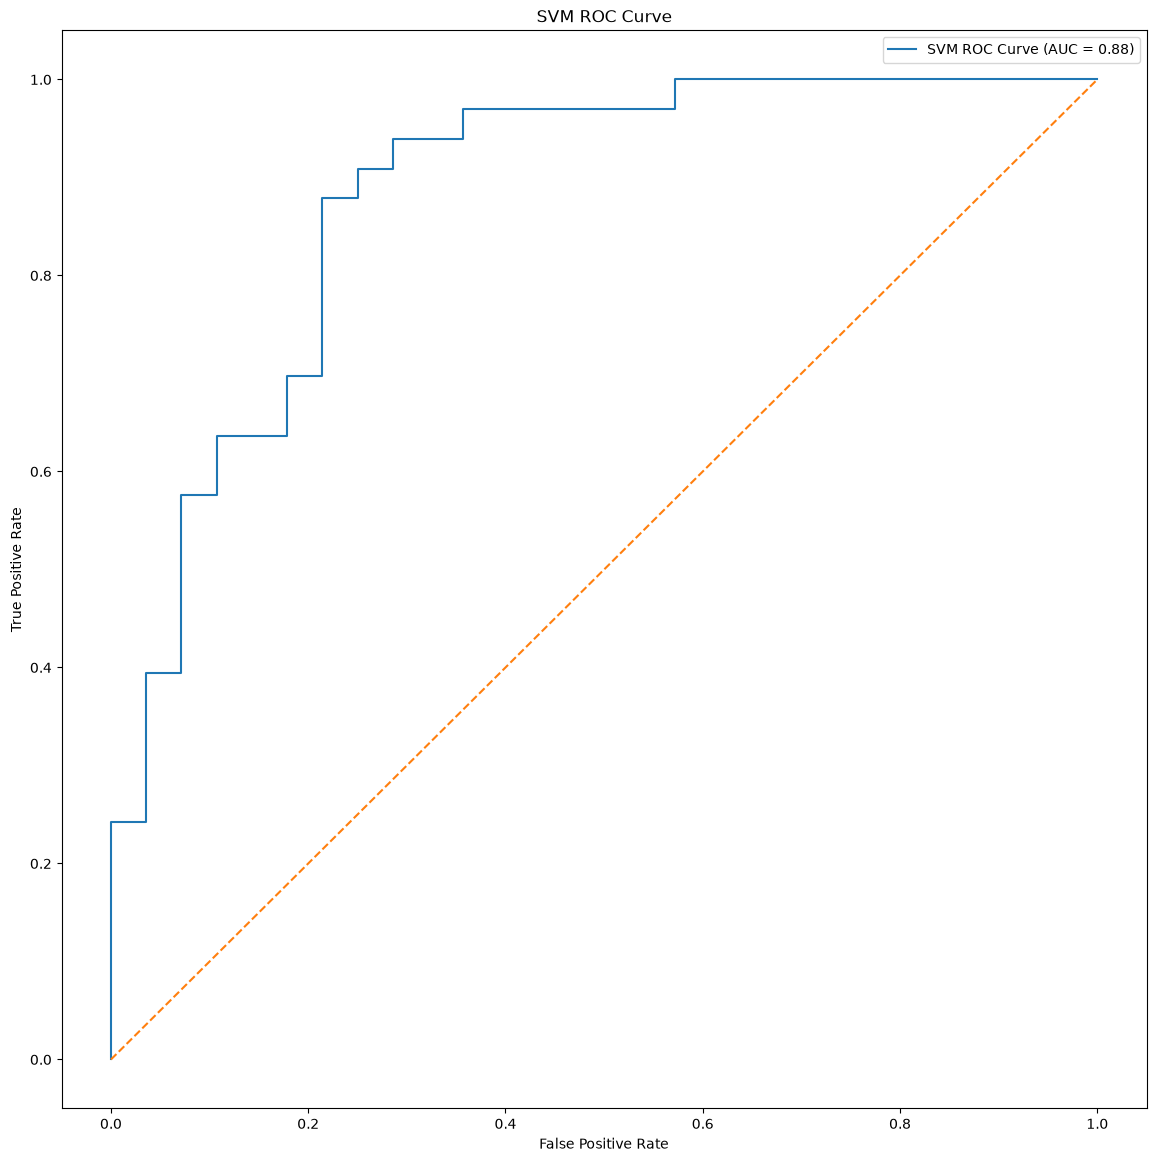

In [144]:
plot_roc_curve(svc_model, X_test, y_test)